# CIS341 - Assignment 1

**Name**: Ho Nok Hei

**Student ID**: S26202765

## import libraries

In [312]:
#only run if Gensim isn't installed
%pip install gensim

Note: you may need to restart the kernel to use updated packages.


In [313]:
#only run if matplotlib isn't installed
%pip install matplotlib

Note: you may need to restart the kernel to use updated packages.


In [314]:
#only run if Gradio isn't installed
%pip install gradio

Note: you may need to restart the kernel to use updated packages.


In [315]:
import sys
import gradio as gr
from typing import LiteralString

# the following lines are for debug only
print("python :", sys.version.split()[0])
print("gradio :", gr.__version__)

major = int(gr.__version__.split(".")[0])

python : 3.12.10
gradio : 6.29.0


## Task 1: GCD and LCM Calculator


**目標**: 輸入兩個整數, 同時顯示它們的最大公因數(GCD)與最小公倍數(LCM). 

### 待辦清單
- [x] `gcdlcm(x, y)` 回傳兩個值：GCD 和 LCM. 
- [x] 輸入可能是數字或文字；轉成整數, 非整數要給清楚訊息. 
- [x] GCD 不為負；恰好一個輸入是 0 時 LCM 是 0；兩個都是 0 時顯示訊息而非數字. 
- [x] 介面有兩個輸入與兩個分開且有標籤的輸出(GCD 一個、LCM 一個). 
- [x] 測試這些配對：`(12, 18)`、`(0, 5)`、`(0, 0)`、`(-8, 12)`, 以及非法輸入如 `abc`. 

**AI use**: 使用 GitHub Copilot 協助解讀規格、檢查邊界情況(0、負數、非整數)與除錯；`gcdlcm` 邏輯與 Gradio 介面由我自行撰寫. 

### code

In [ ]:
# Task 1: GCD and LCM Calculator
import math


def gcdlcm(x, y) -> tuple[int, int | str]:
    """Return two values: (gcd, lcm)."""
    try:
        x, y = int(x), int(y)
        gcd = math.gcd(x, y)
        lcm = (
            math.lcm(x, y) if x != 0 or y != 0 else "LCM undefined (both inputs are 0)"
        )
        return gcd, lcm
    except ValueError:
        raise gr.Error("輸入必須是整數. ")
    except TypeError:
        raise gr.Error("必須填寫所有輸入欄")


demo = gr.Interface(
    fn=gcdlcm,
    inputs=[gr.Textbox(label="輸入 x"), gr.Textbox(label="輸入 y")],
    outputs=[gr.Textbox(label="GCD"), gr.Textbox(label="LCM")],
    title="GCD 和 LCM 計算器",
    description="輸入兩個整數, 計算它們的最大公因數 (GCD) 和最小公倍數 (LCM). ",
)

demo.launch()

* Running on local URL:  http://127.0.0.1:7880
* To create a public link, set `share=True` in `launch()`.


### 測試以及截圖

In [317]:
for pair in [(12, 18), (0, 5), (0, 0), (-8, 12), ("abc", 5)]:
    try:
        print(pair, "->", gcdlcm(*pair))
    except Exception as e:
        print(pair, "-> 錯誤：", e)

(12, 18) -> (6, 36)
(0, 5) -> (5, 0)
(0, 0) -> (0, 'LCM undefined (both inputs are 0)')
(-8, 12) -> (4, 24)
('abc', 5) -> 錯誤： '輸入必須是整數。'


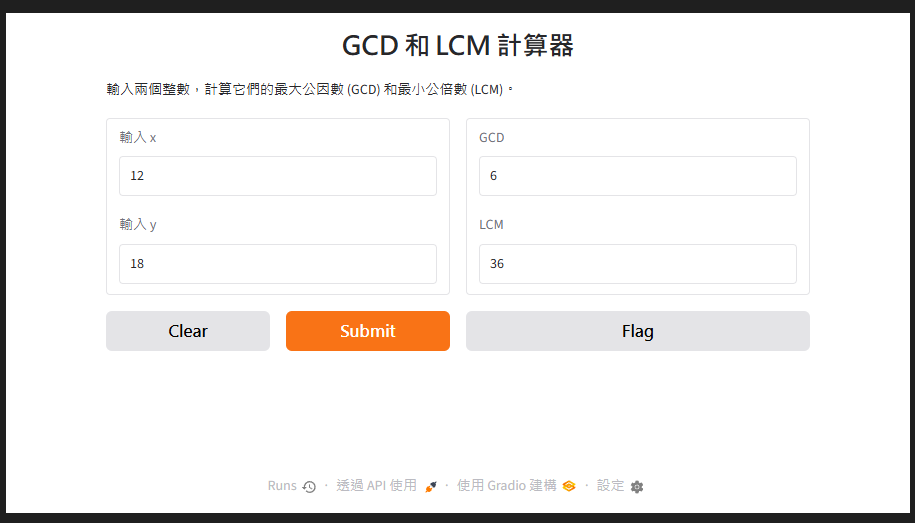
*圖 1：輸入 (12, 18), 顯示 GCD = 6、LCM = 36. *

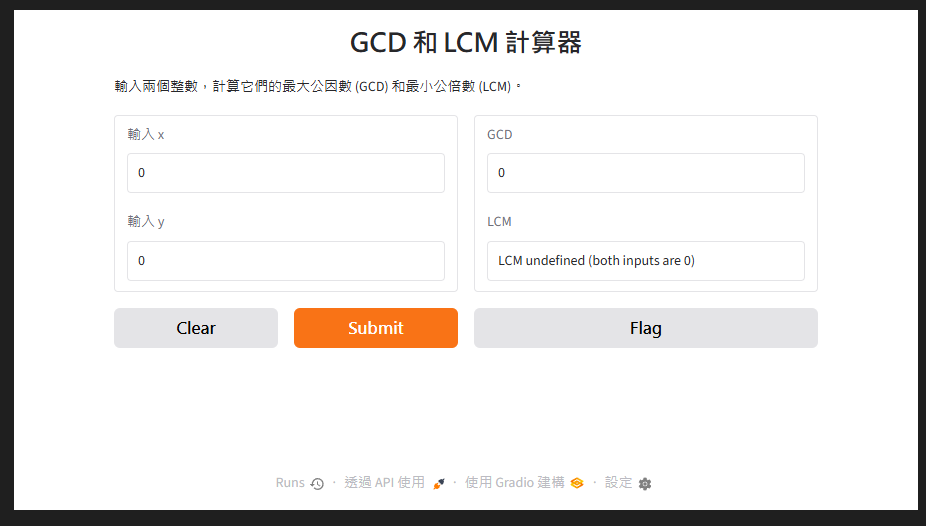
*圖 2：輸入 (0, 0), LCM 顯示「LCM undefined (both inputs are 0)」訊息而非數字. *

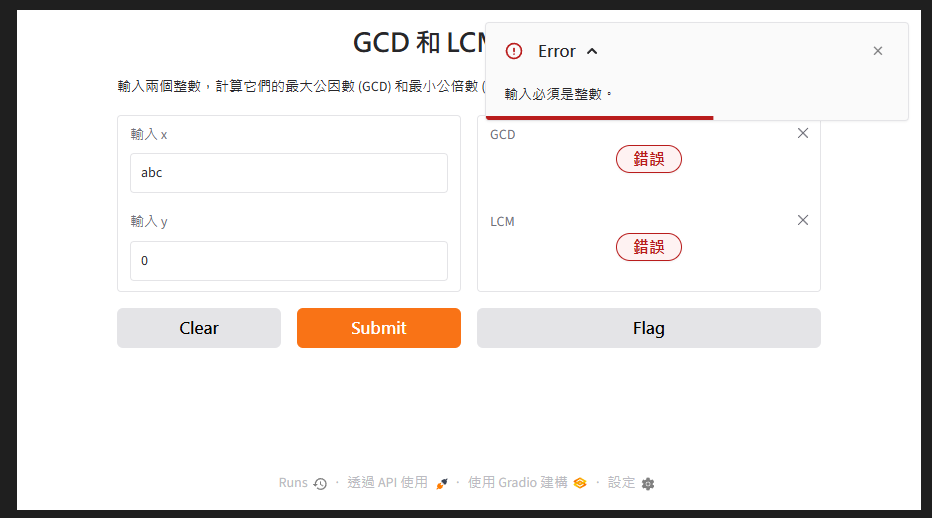
*圖 3：輸入 x=abc, 顯示 gr.Error 訊息「輸入必須是整數. 」, 沒有崩潰. *

## Task 2: Wordle


**目標**: 做一個可玩的 Wordle 遊戲. 電腦隨機選一個 5 字母的祕密單字, 玩家有 6 次機會猜它. 每次猜完, 每個字母會得到一個顏色：綠色(字母在答案中且位置正確)、黃色(字母在答案中但位置不對)、灰色(字母不在答案中). 

### 待辦清單
- [x] `score_guess(secret, guess)` 回傳 5 字元字串(G/Y/X), 且不依賴 Gradio. 
- [x] 重複字母依標準 Wordle 規則：先決定綠色, 再決定黃色, 且每個字母最多只標記它在答案中出現的次數. 
- [x] 使用規格給定的 `WORDS` 清單, 不增不減；新遊戲從中隨機選一個答案. 
- [x] 猜測不是 5 個字母、或不在 `WORDS` 中 → 拒絕並說明原因, 且不消耗次數. 
- [x] 猜測不分大小寫. 
- [x] 猜中或 6 次用完即結束；輸了要顯示答案；結束後再猜要拒絕. 
- [x] New game 按鈕可重新開始. 
- [x] 看板顯示所有猜測與每個字母的顏色, 以及剩餘次數(用真正的彩色磚塊, 例如 `gr.HTML`). 
- [x] 介面有清楚標籤、簡短玩法說明, 使用者能得知猜測被拒絕或遊戲結束. 

**AI use**: 使用 GitHub Copilot 協助解讀規格、設計重複字母的計數演算法(先標綠色、再依剩餘次數標黃色)、檢查邊界情況(空輸入、非 5 字母、不在詞彙表、遊戲結束後再猜)與除錯；`score_guess` 的計分邏輯、`render_board` 的 HTML 看板、`submit`/`new_game` 的遊戲流程與 Gradio 介面由我自行撰寫. 

### code

In [ ]:
import random
from typing import TypedDict


class GuessRecord(TypedDict):
    guess: str
    score: str


WORDS = """
about above actor adult after again agree ahead alarm album alive allow alone apple apron arena argue arise arrow aside audio award badge baker basic beach beard begin below benchberry birth black blade blame blank blast bleed blend block blood bloom board boost booth bound brain brand brave bread break brick bride brief bring broad brown brush build bunch buyer cabin cable candy cargo carry catch cause chain chair chalk charm chart chase cheap check cheek cheer chess chest chief child choir civic claim class clean clear clerk click cliff climb clock close cloud coach coast color couch count court cover crane crash cream crime crowd crown cycle daily dance delay depth dirty doubt dozen draft drama dream dress drink drive eager eagle early earth eerie eight elbow empty enemy enjoy enter entry equal error event every exact exist extra faith false fancy feast fence ferry fever field fifty fight final first flame flash fleet flood floor flour fluid focus force forty found frame fresh fruit funny geese ghost giant glass globe glove grace grade grain grape grass great green greet guard guess guest guide habit happy heart heavy hello honey horse hotel house human humor ideal image index inner input issue jelly jewel joint judge juice knife label labor large laser later laugh layer learn lemon level light limit llama lobby local logic loose lucky lunch magic major maker march match mayor medal metal minor mixer model money month moral motor mount mouse mouth movie music nerve never night noble noise north novel nurse ocean offer often olive onion opera orbit order other outer owner paint panel paper party pasta peace pearl penny phone photo piano piece pilot pizza place plain plane plant plate point pound power press
price pride prize proof proud queen quick quiet radio raise rapid ratio reach react ready relax reply rider right river robot rough round route royal rural salad sauce scale scenescope score sense serve seven shade shake shape share sharp sheep sheet shelf shell shift shine shirt shock shoot short shout sight skill sleep slice small smart smile smoke snake solid solve sound south space spare speak speed spend spice spoon sport staff stage stair stamp stand start steam steel stick still stone store storm story stove straw study style sugar sunny super sweet table taste teach teeth thank theme thick thing think three throw tiger title toast today tooth topic total touch tower trace track trade train treat trend trial truck trust truth twice uncle under unity upper upset urban usual valid value video visit vital voice waste watch water whale wheat wheel white whole woman world worry write wrong young youth zebra
""".split()

WORD_LEN = 5
MAX_ATTEMPTS = 6

# 訊息外框樣式：寬度 100%, 與「猜測」輸入框一致的邊框外觀
MESSAGE_BOX_STYLE = (
    "width:100%;box-sizing:border-box;border:1px solid #d3d6da;"
    "border-radius:8px;padding:8px 12px;min-height:20px;"
)


def message_box(text: str) -> str:
    """
    Wrap a message in a bordered HTML box.

    Parameters
    ----------
    text : str
        The message text to display.

    Returns
    -------
    html : str
        The HTML representation of the message box.
    """
    return f'<div style="{MESSAGE_BOX_STYLE}">{text}</div>'


def score_guess(secret: str, guess: str) -> LiteralString:
    """
    Score a guess against the secret word.

    Parameters
    ----------
    secret : str
        The secret word.
    guess : str
        The guessed word.

    Returns
    -------
    Score : LiteralString
      A string of the same length as the secret word, where each character is:

      - "G" if the letter is correct and in the correct position (green).

      - "Y" if the letter is correct but in the wrong position (yellow).

      - "X" if the letter is incorrect (gray).
    """
    if len(secret) != len(guess):
        raise ValueError("Secret and guess must be the same length.")
    secret = secret.lower()
    guess = guess.lower()
    secret_letters_count = {letter: secret.count(letter) for letter in set(secret)}
    guess_letters_count = {letter: guess.count(letter) for letter in set(guess)}
    extra_guess_letters_count = {
        letter: max(0, guess_letters_count[letter] - secret_letters_count.get(letter, 0))
        for letter in guess_letters_count
    }
    score = []
    for s, g in zip(secret, guess):
        if g == s:
            score.append("G")  # correct letter and position
        elif g in secret and extra_guess_letters_count[g] <= 0:
            score.append("Y")  # correct letter but wrong position
        else:
            score.append("X")  # incorrect letter
            extra_guess_letters_count[g] -= 1
    return "".join(score)


def input_validation(guess: str) -> None:
    """
    Validate the input for the Wordle scoring function.

    Parameters
    ----------
    guess : str
        The guessed word.

    Raises
    ------
    ValueError
        If the guess is not a valid word from the WORDS list.
    """

    if len(guess) != WORD_LEN:
        raise ValueError(f"Guess word '{guess}' isn't {WORD_LEN} letters long.")
    
    if guess not in WORDS:
        raise ValueError(f"Guess word '{guess}' is not in the valid words list.")

def render_board(
    guesses_state: list[GuessRecord],
) -> str:
    """
    Render the Wordle board as HTML.

    Parameters
    ----------
    guesses_state : list[GuessRecord]
        The list of guessed words.

    Returns
    -------
    html : str
        The HTML representation of the Wordle board.
    """
    colors = {"G": "#6aaa64", "Y": "#c9b458", "X": "#787c7e"}
    rows = []
    for i in range(MAX_ATTEMPTS):
        if i < len(guesses_state):
            rec = guesses_state[i]
            tiles = "".join(
                f"""
                <span style="display:inline-block;width:40px;height:40px;
                border:2px solid #d3d6da;
                line-height:40px;text-align:center;
                background:{colors[s]};
                color:white;font-weight:bold;
                border-radius:4px;">
                {c.upper()}
                </span>
                """
                for c, s in zip(rec["guess"], rec["score"])
            )
        else:
            tiles = "".join(
                """
                <span style="display:inline-block;width:40px;height:40px;
                border:2px solid #d3d6da;
                line-height:40px;text-align:center;
                background:white;
                color:white;font-weight:bold;
                border-radius:4px;">
                </span>
                """
                for _ in range(WORD_LEN)
            )
        rows.append(f"<div style='display:block;'>{tiles}</div>")
    attempts_left = MAX_ATTEMPTS - len(guesses_state)
    legend = (
        '<div style="margin-top:12px;font-size:13px;">'
        '<span style="background:#6aaa64;color:white;padding:2px 8px;">right spot</span> '
        '<span style="background:#c9b458;color:white;padding:2px 8px;">in word, wrong spot</span> '
        '<span style="background:#787c7e;color:white;padding:2px 8px;">not in word</span>'
        "</div>"
    )

    return (
        "<div style='font-family:monospace;text-align:center;'>"
        + "<div style='display:grid;grid-template-rows:repeat(5, 40px);gap:4px;'>"
        + "".join(rows)
        + "</div>"
        + f"<div style='margin-top:12px;'>Attempts left: {attempts_left} of {MAX_ATTEMPTS}</div>"
        + legend
        + "</div>"
    )


def submit(new_guess, secret, guesses_state, board):
    """
    Submit a new guess and update the game state.

    Parameters
    ----------
    new_guess : str
        The new guessed word.
    secret : str
        The secret word.
    guesses_state : list[GuessRecord]
        The list of guessed words and their scores.
    board : str
        The current HTML representation of the Wordle board.

    Returns
    -------
    tuple
        A tuple containing the guesses_state, board, and a message.
    """
    if len(secret) != WORD_LEN:
        message = "遊戲狀態丟失請重新開始遊戲. "
        return (guesses_state, board, message_box(message))
    if len(guesses_state) >= MAX_ATTEMPTS:
        message = "沒有剩餘的嘗試次數. 請開始新遊戲. "
        return (guesses_state, board, message_box(message))
    if guesses_state and guesses_state[-1]["score"] == "G" * WORD_LEN:
        message = "你已經贏了！請開始新遊戲. "
        return (guesses_state, board, message_box(message))
    
    try:
        secret = secret.lower()
        new_guess = new_guess.lower()
        input_validation(new_guess)
        new_score = score_guess(secret, new_guess)
    except ValueError as e:
        return (guesses_state, board, message_box(str(e)))
    
    is_won = new_score == "G" * WORD_LEN
    guesses_state = guesses_state + [{"guess": new_guess, "score": new_score}]

    html = render_board(guesses_state)

    if is_won:
        message = "恭喜！你贏了！"
    elif len(guesses_state) >= MAX_ATTEMPTS:
        message = f"遊戲結束！正確答案是 '{secret}'. "
    else:
        message = "目前沒有問題, 有問題會顯示在這裏"
    
    return (
        guesses_state,
        html,
        message_box(message),
    )


def new_game():
    """
    Start a new game by selecting a random secret word and resetting the game state.

    Returns
    -------
    tuple
        A tuple containing the new secret word, an empty guesses_state, the initial board HTML,
        and a message indicating the start of a new game.
    """
    new_secret = random.choice(WORDS)
    return (
        new_secret,
        [],
        render_board([]),
        message_box("新遊戲開始！請輸入 5 字母單字. "),
    )


with gr.Blocks() as demo:
    gr.Markdown("""
        # Wordle
        輸入 5 字母單字, 有 6 次機會. 
        綠=位置對, 黃=字母對位置錯, 灰=沒有. 
        """)

    secret_state = gr.State("")
    guesses_state = gr.State([])

    with gr.Row():
        with gr.Column(scale=1):
            guess_input = gr.Textbox(label="猜測")
            with gr.Row():
                submit_btn = gr.Button("送出")
                new_game_btn = gr.Button("新遊戲")
            message = gr.HTML(
                message_box("目前沒有問題, 有問題會顯示在這裏")
            )

        with gr.Column(scale=2):
            board = gr.HTML()

    new_game_btn.click(
        new_game,
        inputs=[],
        outputs=[
            secret_state, guesses_state, board, message,
        ],
    )

    submit_btn.click(
        submit,
        inputs=[
            guess_input, secret_state, guesses_state, board,
        ],
        outputs=[
            guesses_state, board, message,
        ],
    )

    demo.load(
        new_game,  # 要執行的函式
        inputs=[],  # 不需要輸入
        outputs=[secret_state, guesses_state, board, message],
    )

demo.launch()

* Running on local URL:  http://127.0.0.1:7881
* To create a public link, set `share=True` in `launch()`.


### 測試以及截圖

In [319]:
cases = [
    ("CRANE", "HOUSE", "XXXXG"),   # 題目中的例子
    ("CRANE", "REACT", "YYGYX"),   # 題目中的例子
    ("CRANE", "TRACE", "XGGYG"),   # 題目中的例子
    ("apple", "ppppp", "XGGXX"),   # 重複字母
    ("about", "about", "GGGGG"),   # 全對
    ("about", "zzzzz", "XXXXX"),   # 全錯
    ("eerie", "reeei", "YGYYY"),   # 同字母重排 1
    ("crane", "nacre", "YYYYG"),   # 同字母重排 2
    ("ababba", "aabbaa", None), # 同字母重排 3
]
for secret, guess, expected in cases:
    got = score_guess(secret, guess)
    ok = "OK " if (expected is None or got == expected) else "FAIL"
    print(f"{ok} secret={secret!r:9} guess={guess!r:9} -> {got}  (expected {expected})")

OK  secret='CRANE'   guess='HOUSE'   -> XXXXG  (expected XXXXG)
OK  secret='CRANE'   guess='REACT'   -> YYGYX  (expected YYGYX)
OK  secret='CRANE'   guess='TRACE'   -> XGGYG  (expected XGGYG)
OK  secret='apple'   guess='ppppp'   -> XGGXX  (expected XGGXX)
OK  secret='about'   guess='about'   -> GGGGG  (expected GGGGG)
OK  secret='about'   guess='zzzzz'   -> XXXXX  (expected XXXXX)
OK  secret='eerie'   guess='reeei'   -> YGYYY  (expected YGYYY)
OK  secret='crane'   guess='nacre'   -> YYYYG  (expected YYYYG)
OK  secret='ababba'  guess='aabbaa'  -> GXYGYG  (expected None)


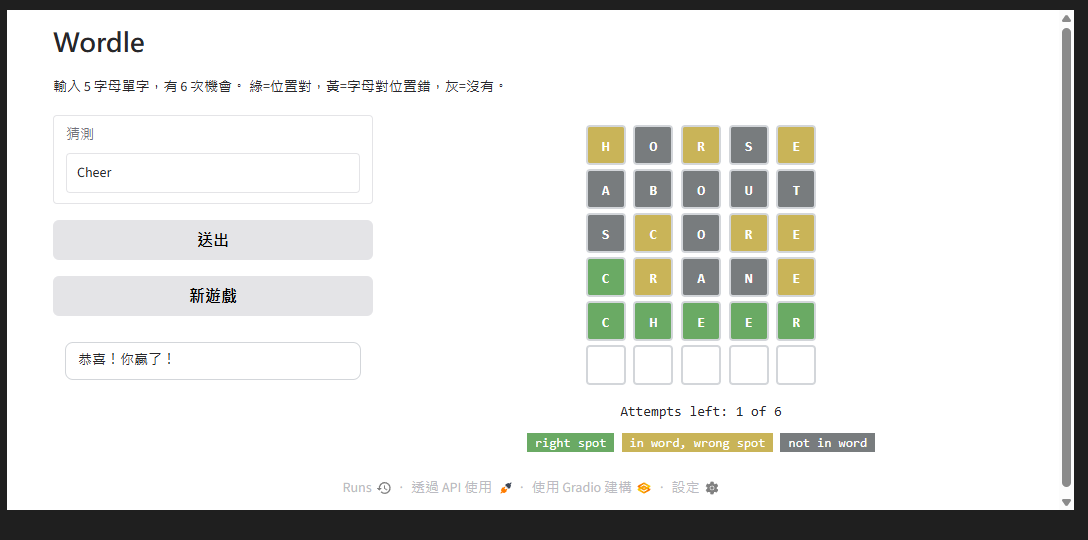
成功解答例子

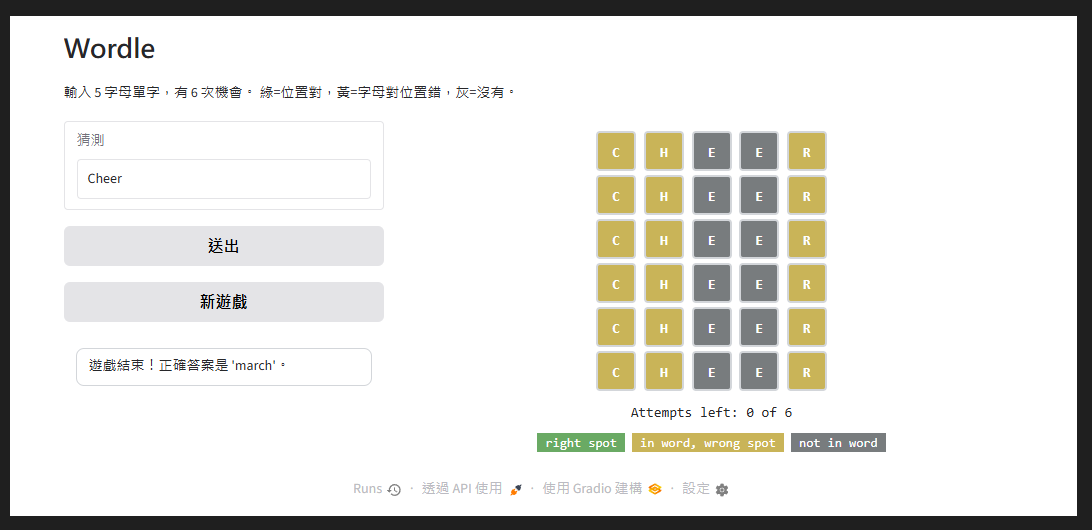
失敗例子

## Task 3: Image Gallery

**目標**: 做一個小型Image Gallery app, 使用者可以列出、上傳與刪除圖片. 

### 待辦清單
- [x] 清單：gallery 永遠顯示目前儲存的所有圖片；空的時候顯示合理訊息而非錯誤. 
- [x] 上傳：使用者選任意圖片, 加入 gallery 成為新項目. 
- [x] 選取與刪除：點擊 gallery 中的圖片可選取, 刪除動作只移除該張圖片. 
- [x] 邊界情況：沒選檔案就上傳、或沒選取就刪除 → 給訊息且不改變任何東西；刪除後不能殘留指向別張圖的舊選取. 
- [x] 順序：決定新圖片出現在最前或最後, 並在描述中說明, 且保持一致. 
- [x] 版面：每個操作有獨立控制項(例如 `gr.Blocks` 搭配獨立按鈕). 

**AI use**: 使用 GitHub Copilot 協助解讀規格、查詢 `gr.Gallery` 的 `select` 事件與 `gr.SelectData` 用法、設計 CSS 讓縮圖固定 192×192 並自動換行置中、以及除錯(`gr.Blocks` 的 `css` 參數在 Gradio 6 已移到 `launch()`、`min-height` 會蓋掉 `max-height`)；`render_gallery`/`add_image`/`select_image`/`delete_image` 的邏輯、`gr.State` 的選取狀態管理與整體版面由我自行撰寫. 

### code

In [ ]:
# 縮圖固定大小(px)
THUMB_SIZE = 192
# 縮圖之間的間距(px)
GAP = 8
# gallery 可視高度(px)：顯示 2 行縮圖
#   = 2 行縮圖 + 1 個 row-gap + 上下 padding(各 8px)
GALLERY_HEIGHT = 2 * THUMB_SIZE + GAP + 16

GALLERY_CSS = f"""
#gallery .grid-wrap {{
    height: {GALLERY_HEIGHT}px !important;
    max-height: {GALLERY_HEIGHT}px !important;
    min-height: {GALLERY_HEIGHT}px !important;
    overflow-y: auto !important;
}}
#gallery .grid-container {{
    grid-template-columns: repeat(auto-fill, {THUMB_SIZE}px) !important;
    gap: {GAP}px !important;
    justify-content: center !important;
}}
#gallery .gallery-item,
#gallery .thumbnail-item {{
    width: {THUMB_SIZE}px !important;
    height: {THUMB_SIZE}px !important;
}}
.equal-height-row {{
    align-items: stretch;
}}
.equal-height-row > .cell-box {{
    height: auto;
    display: flex;
    flex-direction: column;
}}
.cell-box {{
    border: 2px solid #d3d6da;
    border-radius: 8px;
    padding: 4px;
    height: 100%;
}}
.align-items-stretch {{
    display: flex;
    align-items: stretch;
}}
"""

# Must 1: 空 gallery 要顯示合理訊息, 而不是錯誤. 
EMPTY_GALLERY_MSG = "目前沒有任何圖片, 請從左邊上傳. "

def render_gallery(images: list[str]) -> tuple[list[str], str]:
    """
    依圖片清單產生 gallery 的顯示內容與狀態訊息. 

    Parameters
    ----------
    images : list[str]
        目前儲存的圖片檔案路徑清單. 

    Returns
    -------
    tuple
        (gallery 要顯示的圖片清單, 狀態訊息). 
    """
    # Must 1: gallery 永遠顯示目前儲存的所有圖片
    if not images:
        return [], EMPTY_GALLERY_MSG
    return images, f"目前共有 {len(images)} 張圖片. "


# Must 2: 上傳圖片
def add_image(new_image: str | None, images: list[str]):
    """
    把使用者選的圖片加入 gallery. 

    Parameters
    ----------
    new_image : str | None
        使用者選的圖片路徑；沒選檔案時為 None. 
    images : list[str]
        目前儲存的圖片清單. 

    Returns
    -------
    tuple
        (更新後的圖片清單, gallery 顯示內容, 狀態訊息, 清空後的圖片輸入). 
    """
    # Must 4: 沒選檔案就上傳 → 給訊息且不改變任何東西
    if new_image is None:
        gallery_items, msg = render_gallery(images)
        return images, gallery_items, f"{msg}\n請先選擇一張圖片再按「加入」. ", None

    # Must 5: 新圖片加在最後
    images = images + [new_image]
    gallery_items, msg = render_gallery(images)
    return images, gallery_items, f"{msg}\n已加入圖片. ", None


# Must 3: 選取圖片(讀 gr.SelectData 的 index)
def select_image(evt: gr.SelectData):
    """
    記錄使用者點選的圖片索引. 

    Parameters
    ----------
    evt : gr.SelectData
        gallery 的選取事件, 索引在 evt.index. 

    Returns
    -------
    tuple
        (選取的索引, 狀態訊息). 
    """
    index = evt.index
    return index, f"已選取第 {index + 1} 張圖片. "


# Must 3 + Must 4: 刪除選取的圖片, 並清掉選取狀態
def delete_image(selected_index: int | None, images: list[str]):
    """
    刪除目前選取的圖片, 並清空選取狀態. 

    Parameters
    ----------
    selected_index : int | None
        目前選取的索引；沒有選取時為 None. 
    images : list[str]
        目前儲存的圖片清單. 

    Returns
    -------
    tuple
        (更新後的圖片清單, gallery 顯示內容, 狀態訊息, 清空後的選取索引). 
    """
    # Must 4: 沒選取就刪除 → 給訊息且不改變任何東西
    if selected_index is None or not (0 <= selected_index < len(images)):
        gallery_items, msg = render_gallery(images)
        return images, gallery_items, f"{msg}\n請先在 gallery 中點選一張圖片. ", None, "尚未選取圖片"

    # Must 3: 只移除被選取的那一張
    images = images[:selected_index] + images[selected_index + 1 :]
    gallery_items, msg = render_gallery(images)
    # Must 4: 刪除後清空選取, 避免殘留指向別張圖的舊選取
    return images, gallery_items, f"{msg}\n已刪除圖片. ", None, "尚未選取圖片"


with gr.Blocks(title="Image Gallery") as demo:
    gr.Markdown("## Task 3: Image Gallery")

    # Session 狀態
    images_state = gr.State([])          # 圖片路徑清單
    selected_state = gr.State(None)      # 目前選取的索引

    with gr.Row(elem_classes="equal-height-row"):
        with gr.Column(scale=1, elem_classes="cell-box"):
            gr.Markdown("## 上傳")
            upload = gr.Image(
                label="選擇一張圖片",
                type="filepath",
                sources=["upload"],
            )
            add_btn = gr.Button("加入 Gallery")
            status = gr.Textbox(label="狀態", value=EMPTY_GALLERY_MSG, interactive=False)
        
        with gr.Column(scale=2, elem_classes="cell-box"):
            gr.Markdown("## Gallery")
            gallery = gr.Gallery(
                label="Gallery",
                show_label=False,
                elem_id="gallery",
                allow_preview=False,   # 關閉放大預覽
            )
            with gr.Row(elem_classes="align-items-stretch"):
                selected = gr.Textbox(
                    label="已選取的圖片", elem_id="selected-image", interactive=False,
                    value="尚未選取圖片"
                )
                del_btn = gr.Button("刪除選取的圖片")
            gr.Markdown(
                "點擊圖片即可選取(會顯示橘色外框), 再按「刪除選取的圖片」把它從 Gallery 移除. "
            )

    # Must 2: 上傳
        add_btn.click(
            add_image,
            inputs=[upload, images_state],
            outputs=[images_state, gallery, status, upload],
        )

        # Must 3 + Must 4: 刪除
        del_btn.click(
            delete_image,
            inputs=[selected_state, images_state],
            outputs=[images_state, gallery, status, selected_state, selected],
        )

        # Must 3: 選取
        gallery.select(
            select_image,
            inputs=[],
            outputs=[selected_state, selected],
        )
    
demo.launch(css=GALLERY_CSS)

* Running on local URL:  http://127.0.0.1:7882
* To create a public link, set `share=True` in `launch()`.


### 測試以及截圖

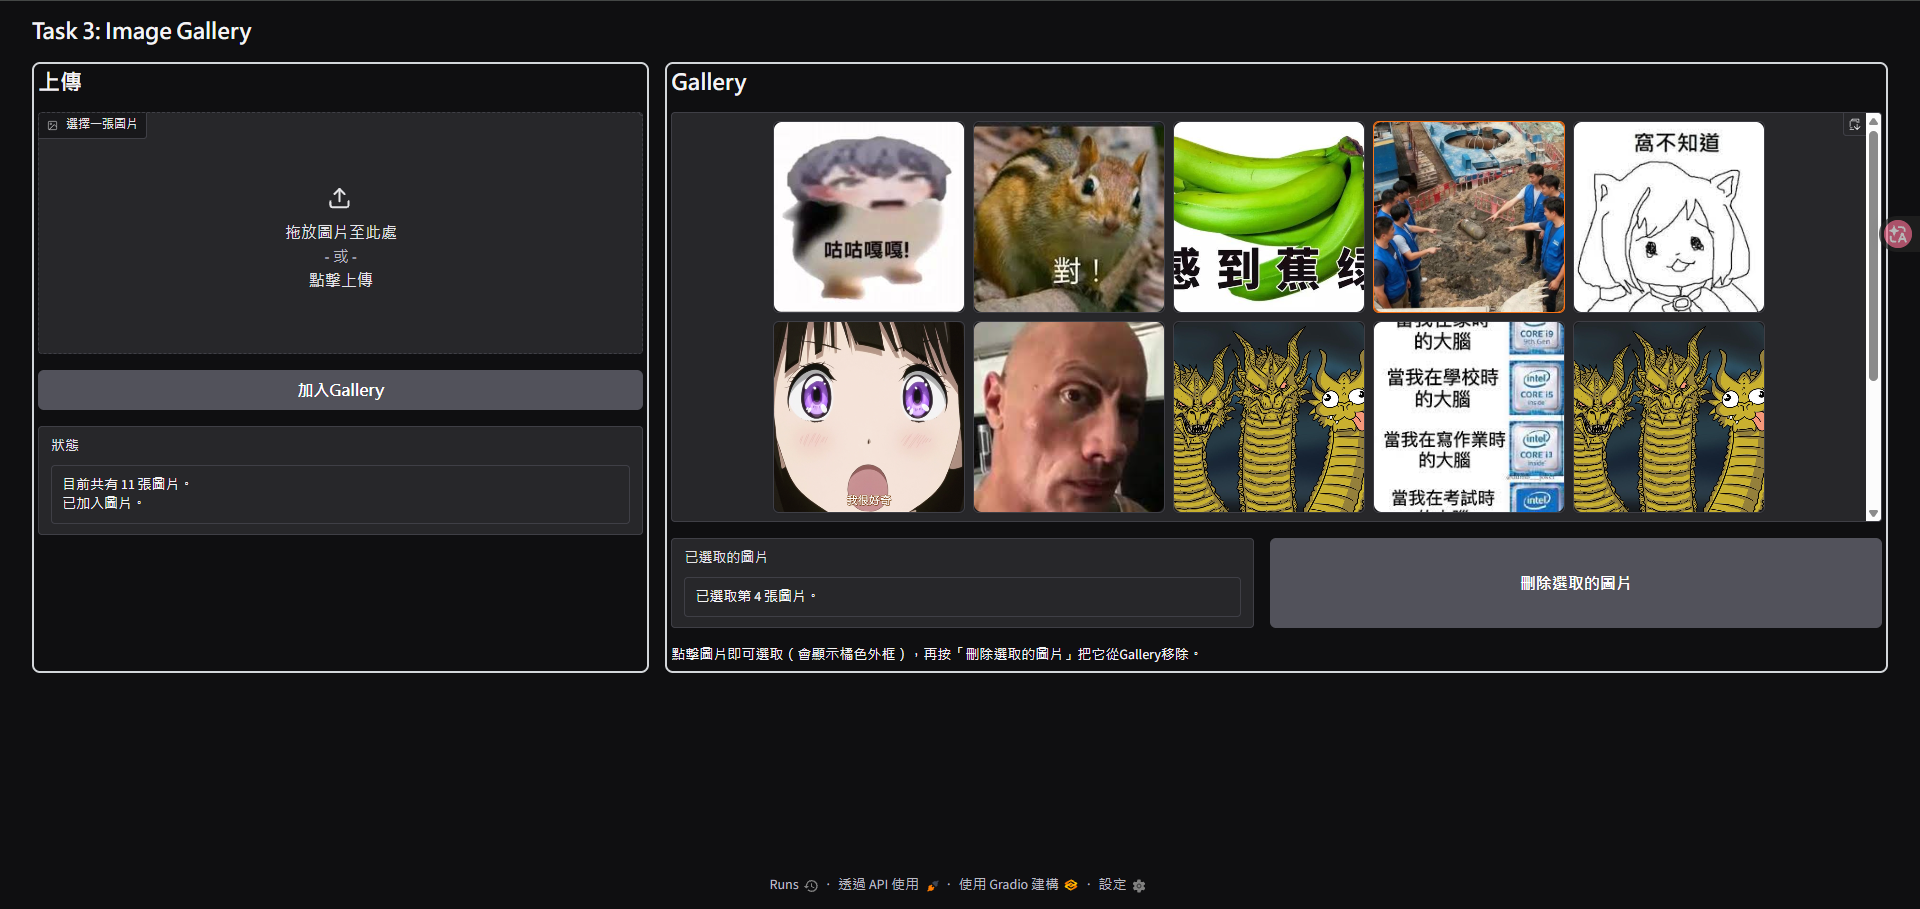
*Gallery 中共有 11 張圖片, 點擊第 4 張後顯示橘色外框, 狀態列顯示「已選取第 4 張圖片」. *

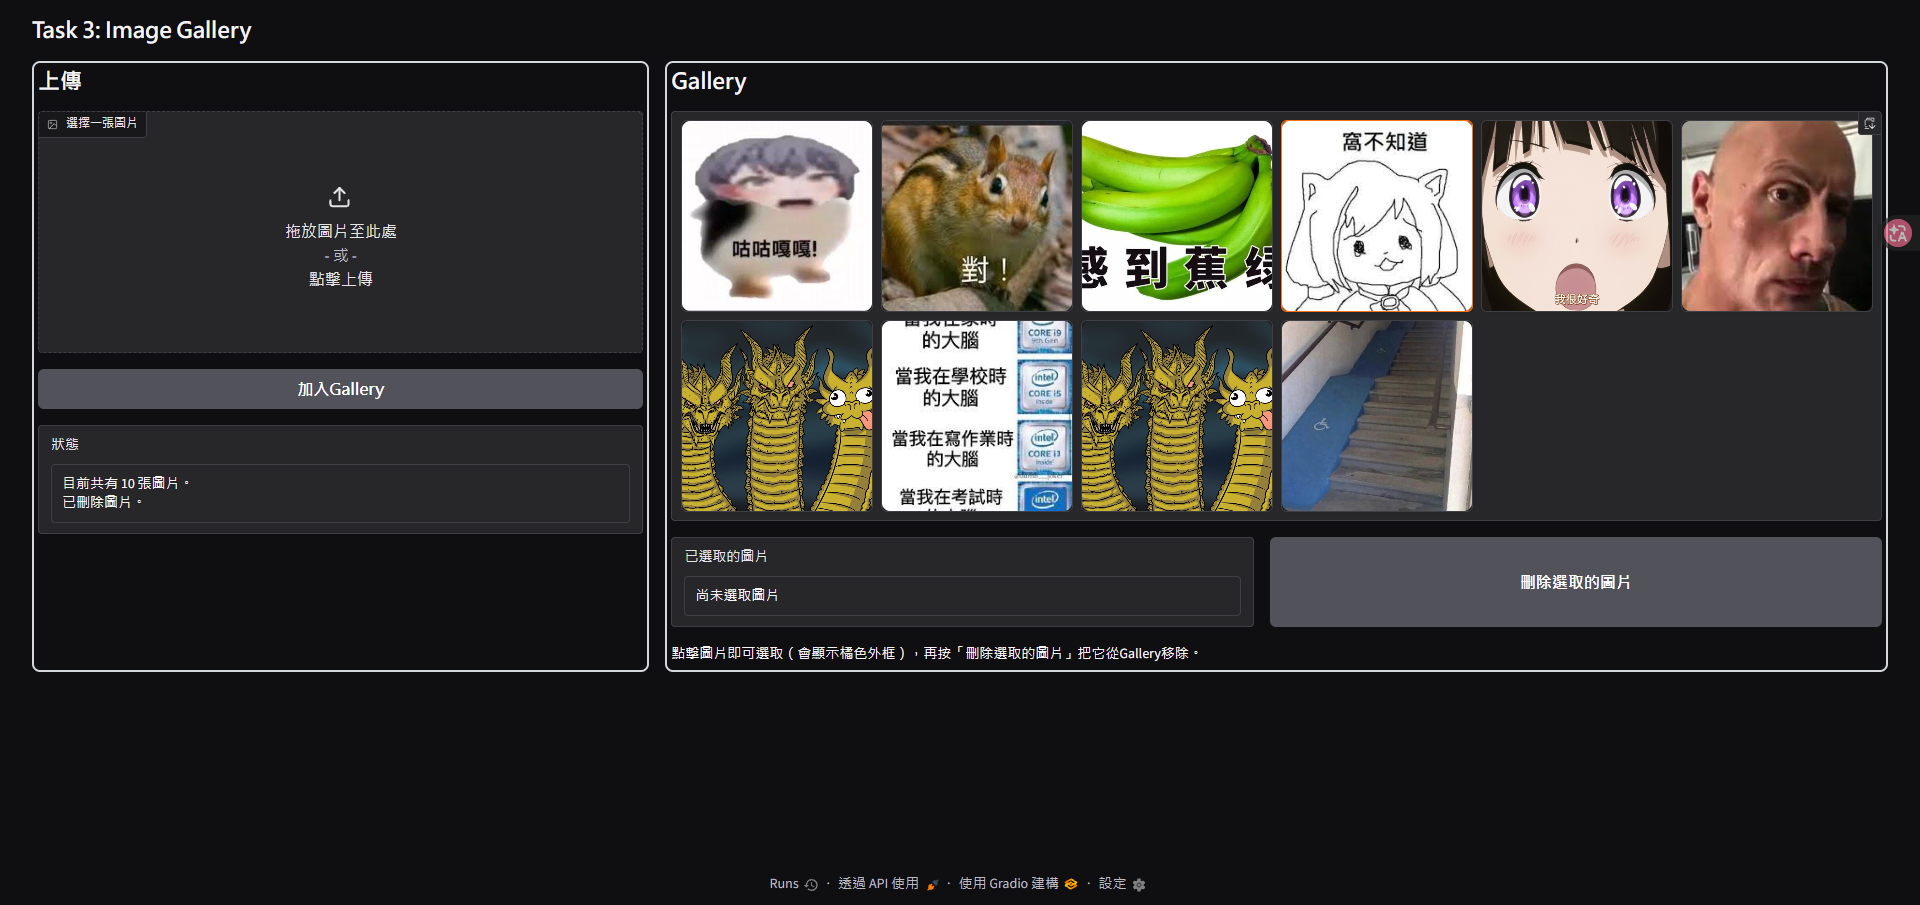
*按下「刪除選取的圖片」後, Gallery 剩下 10 張圖片, 狀態列顯示「已刪除圖片」. *

## Task 4: Word Analogy Solver


**目標**: 用預訓練的詞向量解「A 對 B 如同 C 對 D」形式的類比. 使用者輸入三個字 A、B、C, app 預測缺少的字 D. 

### 待辦清單
- [x] 模型：用 `gensim.downloader` 載入 `glove-wiki-gigaword-100`, 在獨立儲存格載入一次, 不要在 Gradio 函式內載入. 
- [x] 目標向量：依圖示用向量運算自行計算目標點(不可用現成的類比求解函式). 
- [x] 檢索：用 cosine similarity 找最接近的 5 個字, 排除 A、B、C, 由高到低排序並附分數；第一名即預測的 D. 
- [x] 輸入處理：輸入轉小寫；字不在詞彙表中要指出是哪個字；兩個輸入相同要警告使用者. 
- [x] 顯示：三個清楚標籤的輸入；D 要醒目顯示；前 5 名用 `gr.Label` 呈現；描述要說明「A is to B as C is to D」並附例子. 
- [x] 測試：至少五個不同類型的類比(如性別、國家首都、動詞時態、比較級), 其中一個要失敗, 並寫一句說明為何失敗. 

**AI use**: 使用 GitHub Copilot 協助解讀規格、查詢 `gensim` 的 `KeyedVectors` API(`most_similar`、`key_to_index`、`index_to_key`)與 `gr.Label` 的用法、以及除錯(`most_similar` 回傳的是 `(word, score)` tuple 而非純字串、`glove-wiki-gigaword-100` 的詞彙表不含大小寫變體)；目標向量的向量運算(`vec(B) - vec(A) + vec(C)`)、cosine similarity 排序、排除輸入詞與失敗案例的分析由我自行撰寫. 

### code

In [321]:
import gensim.downloader as api
from gensim.models import KeyedVectors
from typing import cast


model = cast(KeyedVectors, api.load("glove-wiki-gigaword-100"))

In [ ]:
T4_CSS = f"""
.equal-height-row {{
    align-items: stretch;
}}
.equal-height-row > .cell-box {{
    height: auto;
    display: flex;
    flex-direction: column;
}}
.cell-box {{
    border: 2px solid #d3d6da;
    border-radius: 8px;
    padding: 4px;
    height: 100%;
}}
.align-items-stretch {{
    display: flex;
    align-items: stretch;
}}
#top5 {{
    flex-grow: 1 !important;
    display: flex !important;
    flex-direction: column !important;
}}
#top5 > .wrap {{
    flex-grow: 1 !important; /* 強迫 Gradio 的 Label 包裹層長高 */
}}
"""

def solve_analogy(word1: str, word2: str, word3: str):
    """
    Solve the word analogy problem: "word1 is to word2 as word3 is to ?".

    ```important mention
    Compute the target point yourself with vector arithmetic in your own code, following
    the figure. A library function that solves the whole analogy for you does not count for this part.
    ```
    Parameters
    ----------
    word1 : str
        The first word in the analogy (A).
    word2 : str
        The second word in the analogy (B).
    word3 : str
        The third word in the analogy (C).
    Returns
    -------
    tuple
        A tuple containing the predicted word (D), a list of the top 5 predictions,
        and a status message indicating success or failure.
    """
    predicted_word = ""
    top5_predictions = {}
    status_message = ""

    try:
        # Convert words to lowercase
        word1 = word1.lower()
        word2 = word2.lower()
        word3 = word3.lower()

        # Check if all words are in the model's vocabulary
        if word1 not in model.key_to_index: # pyright: ignore[reportOperatorIssue]
            raise ValueError(f"Word '{word1}' is not in the model's vocabulary.")
        if word2 not in model.key_to_index: # pyright: ignore[reportOperatorIssue]
            raise ValueError(f"Word '{word2}' is not in the model's vocabulary.")
        if word3 not in model.key_to_index: # pyright: ignore[reportOperatorIssue]
            raise ValueError(f"Word '{word3}' is not in the model's vocabulary.")

        if word1 == word2 or word1 == word3 or word2 == word3:
            raise ValueError("All three words must be distinct.")

        # Compute the target vector using vector arithmetic
        target_vector = model[word2] - model[word1] + model[word3]  # pyright: ignore[reportIndexIssue]

        # Find the most similar words to the target vector
        candidates = model.similar_by_vector(target_vector, topn=20) # pyright: ignore[reportCallIssue]
        excluded = {word1, word2, word3}
        top5_predictions = {
            word: float(score)
            for word, score in candidates
            if word not in excluded
        }
        top5_predictions = dict(list(top5_predictions.items())[:5])
        # The predicted word is the top prediction
        predicted_word = next(iter(top5_predictions))
        status_message = "成功找到類比關係. "


        return predicted_word, top5_predictions, status_message
    except ValueError as ve:
        status_message = str(ve)
        return "", {}, status_message
    except Exception as e:
        status_message = f"發生錯誤: {str(e)}"
        return "", {}, status_message
    

def clear_fields():
    """
    Clear the input and output fields in the Word Analogy Solver.

    Returns
    -------
    tuple
        A tuple containing empty strings for the input and output fields, and a status message.
    """
    return "", "", "", "", {}, "請輸入三個單字並按「Solve Analogy」"

with gr.Blocks() as demo:
    gr.Markdown("## Task 4: Word Analogy Solver")

    with gr.Row(elem_classes="equal-height-row"):
        with gr.Column(scale=2, elem_classes="cell-box"):
            word1 = gr.Textbox(label="A: src 1", placeholder="輸入一個單字")
            word2 = gr.Textbox(label="B: what A becomes", placeholder="輸入一個單字")
            word3 = gr.Textbox(label="C: src 2", placeholder="輸入一個單字")
            with gr.Row():
                solve_btn = gr.Button("Solve Analogy")
                clear_btn = gr.Button("Clear")
            status = gr.Textbox(label="Status", value="請輸入三個單字並按「Solve Analogy」", interactive=False)

        with gr.Column(scale=3, elem_classes="cell-box"):
            result = gr.Textbox(label="Predicted D", interactive=False)
            top5 = gr.Label(label="Top 5 Predictions", num_top_classes=5, elem_id="top5")

    solve_btn.click(
        solve_analogy,
        inputs=[word1, word2, word3],
        outputs=[result, top5, status],
    )

    clear_btn.click(
        clear_fields,
        inputs=[],
        outputs=[word1, word2, word3, result, top5, status],
    )

demo.launch(css=T4_CSS)

* Running on local URL:  http://127.0.0.1:7883
* To create a public link, set `share=True` in `launch()`.


### 測試以及截圖

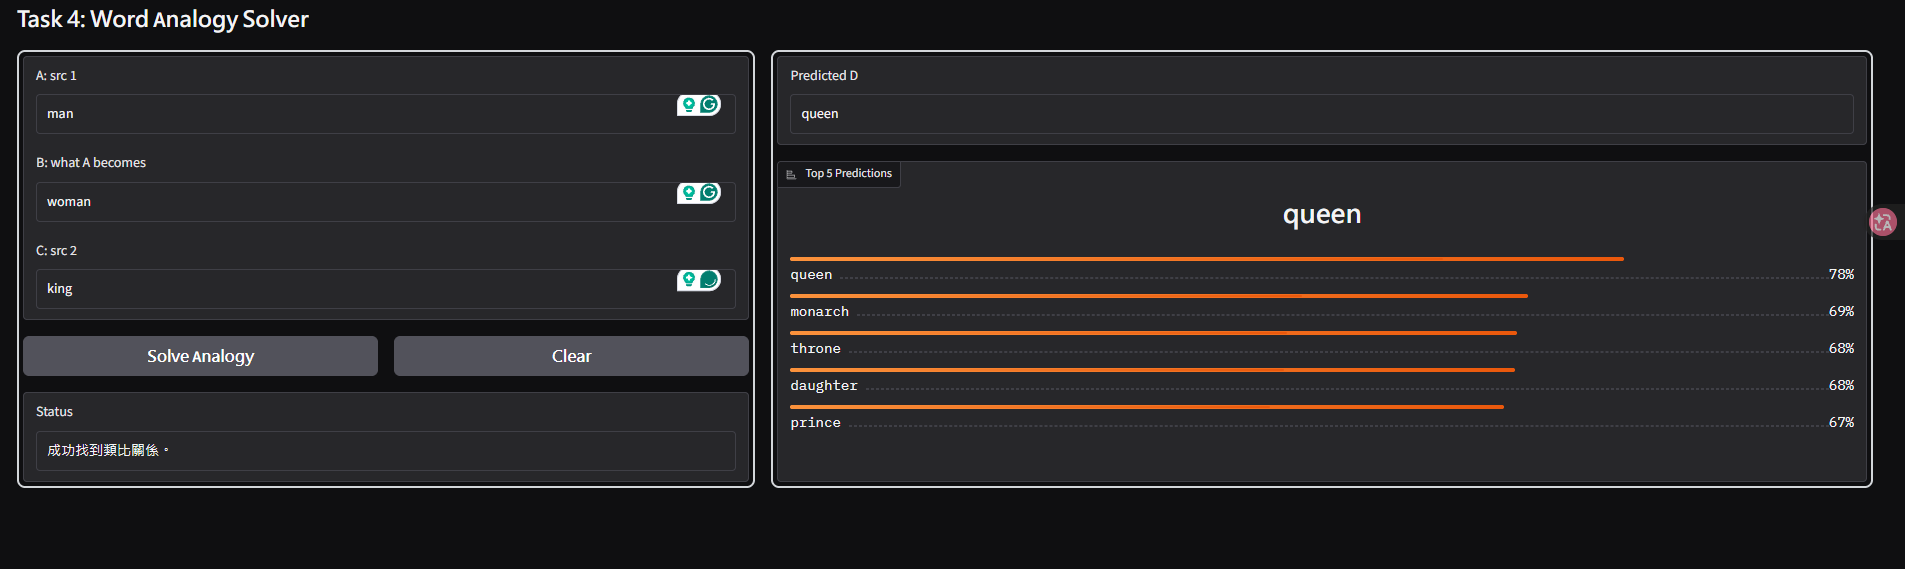
*圖 1(性別類比, 成功)：`man : woman :: king : ?` 預測 `queen`(78%), Top 5 為 queen / monarch / throne / daughter / prince, 全部是皇室或性別相關詞, 向量方向乾淨. *

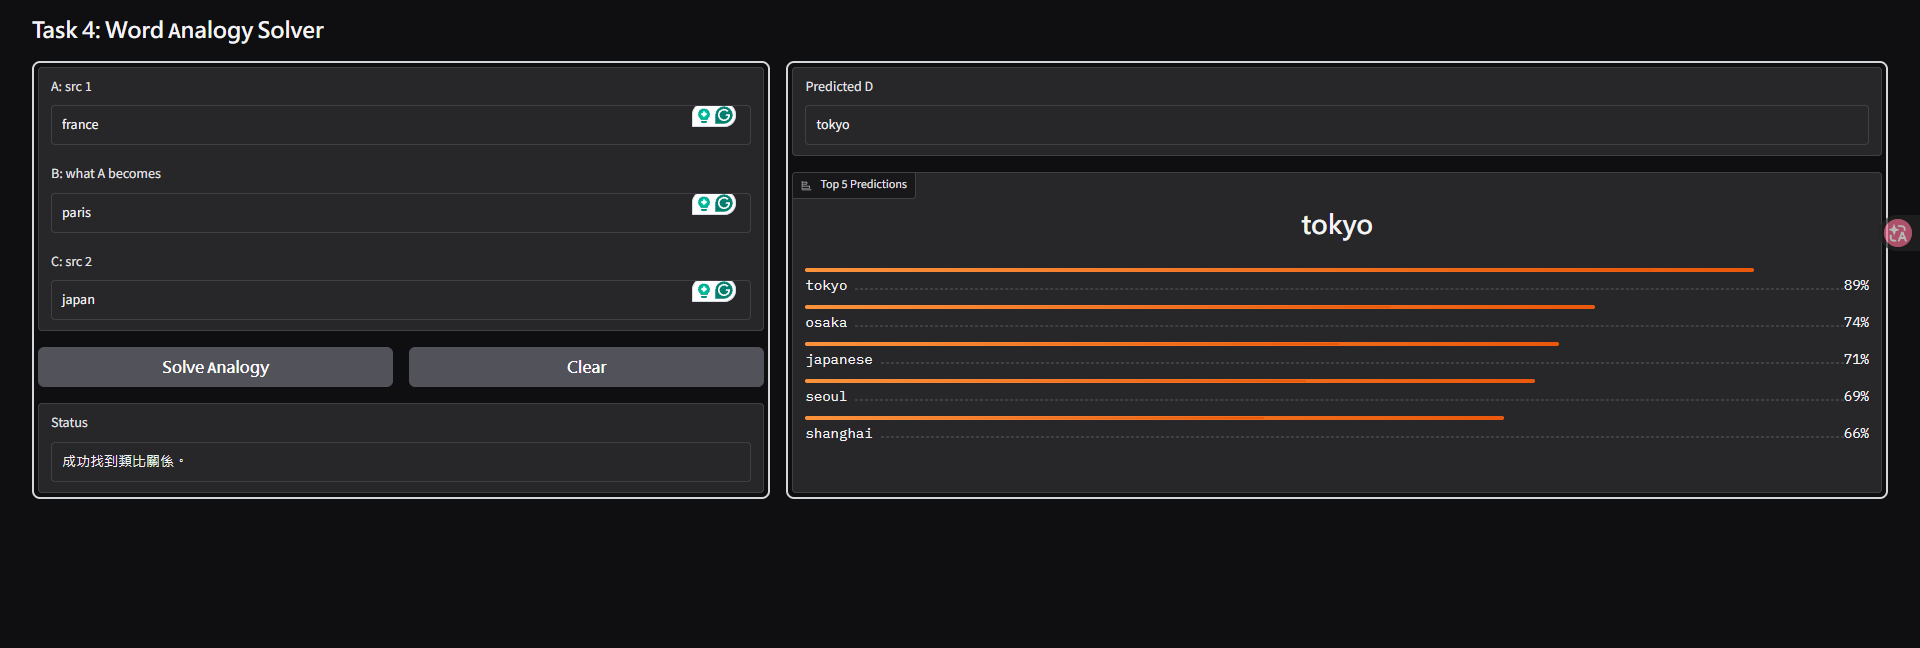
*圖 2(國家首都類比, 成功)：`france : paris :: japan : ?` 預測 `tokyo`(89%), Top 5 為 tokyo / osaka / japanese / seoul / shanghai, 首都與亞洲城市詞主導, 分數最高代表關係最明確. *

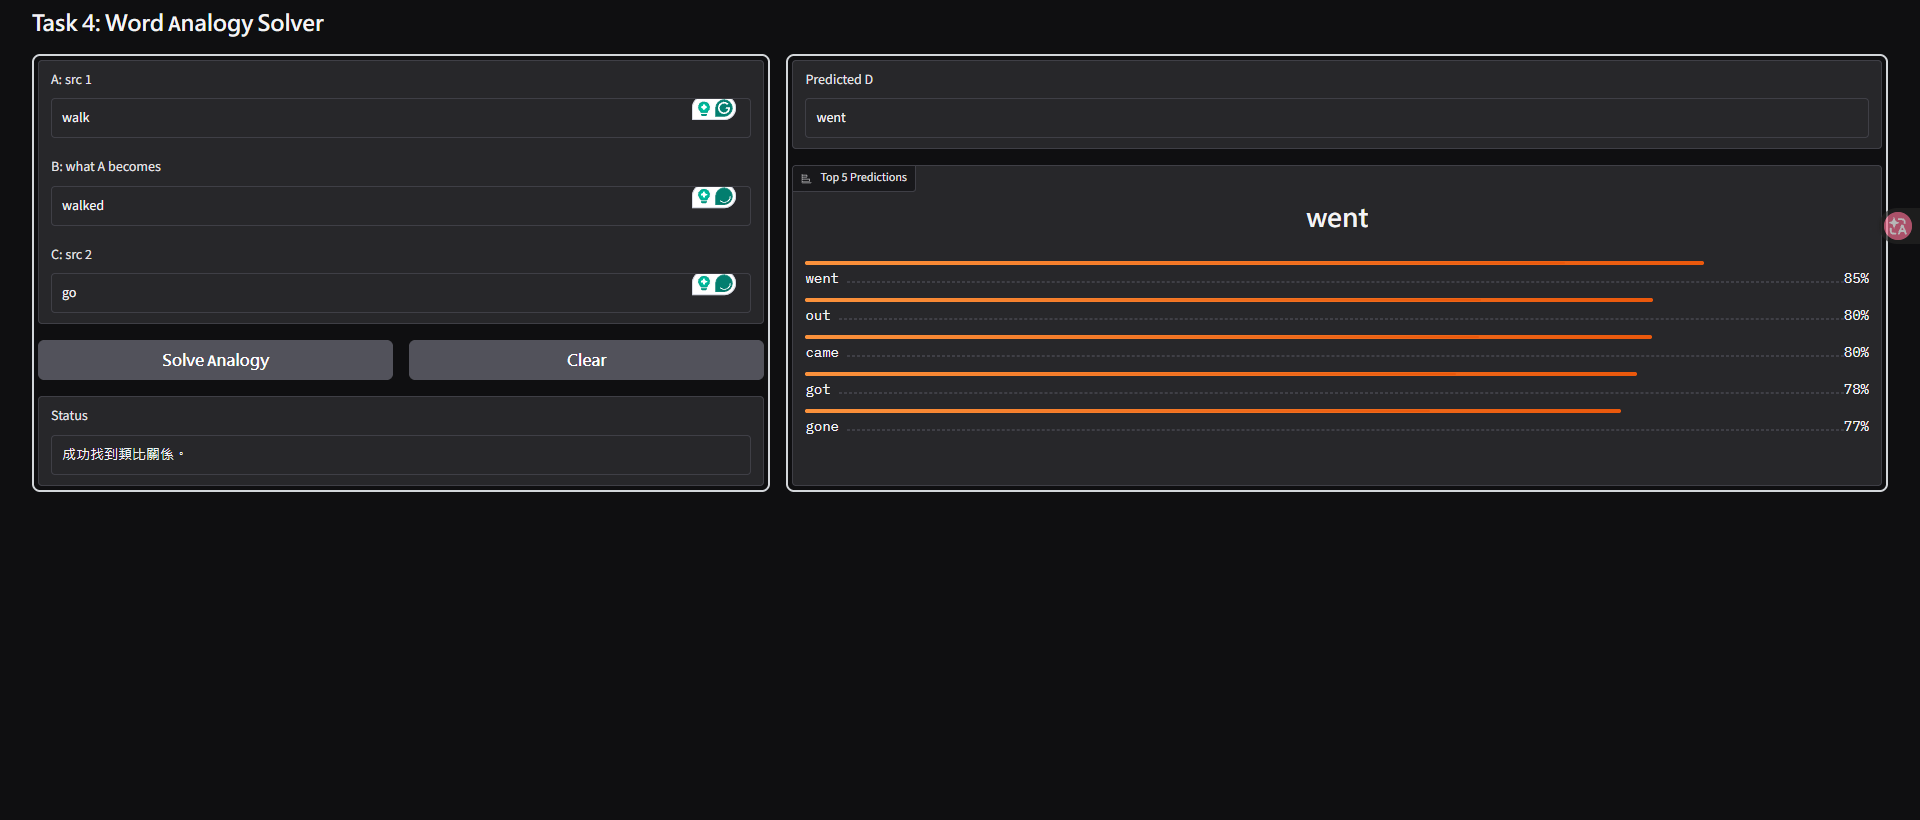
*圖 3(動詞時態類比, 成功)：`walk : walked :: go : ?` 預測 `went`(85%), Top 5 為 went / out / came / got / gone, 正確抓到過去式關係(`go` 的不規則過去式). *

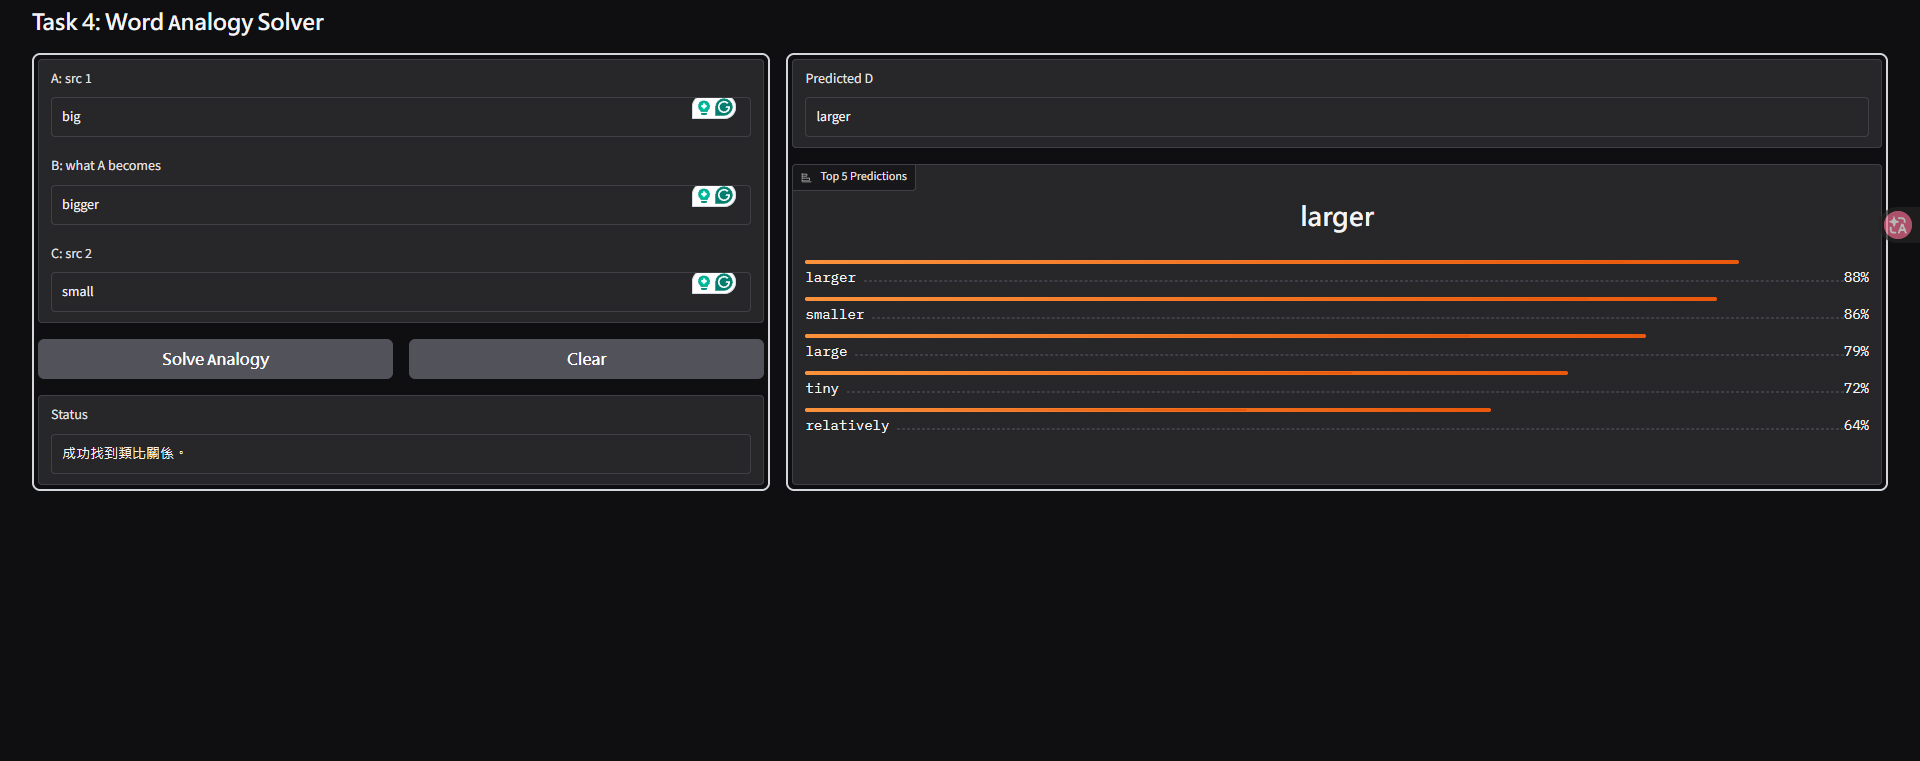
*圖 4(比較級類比, 成功)：`big : bigger :: small : ?` 預測 `larger`(88%), Top 5 為 larger / smaller / large / tiny / relatively, 皆為大小比較相關詞. *

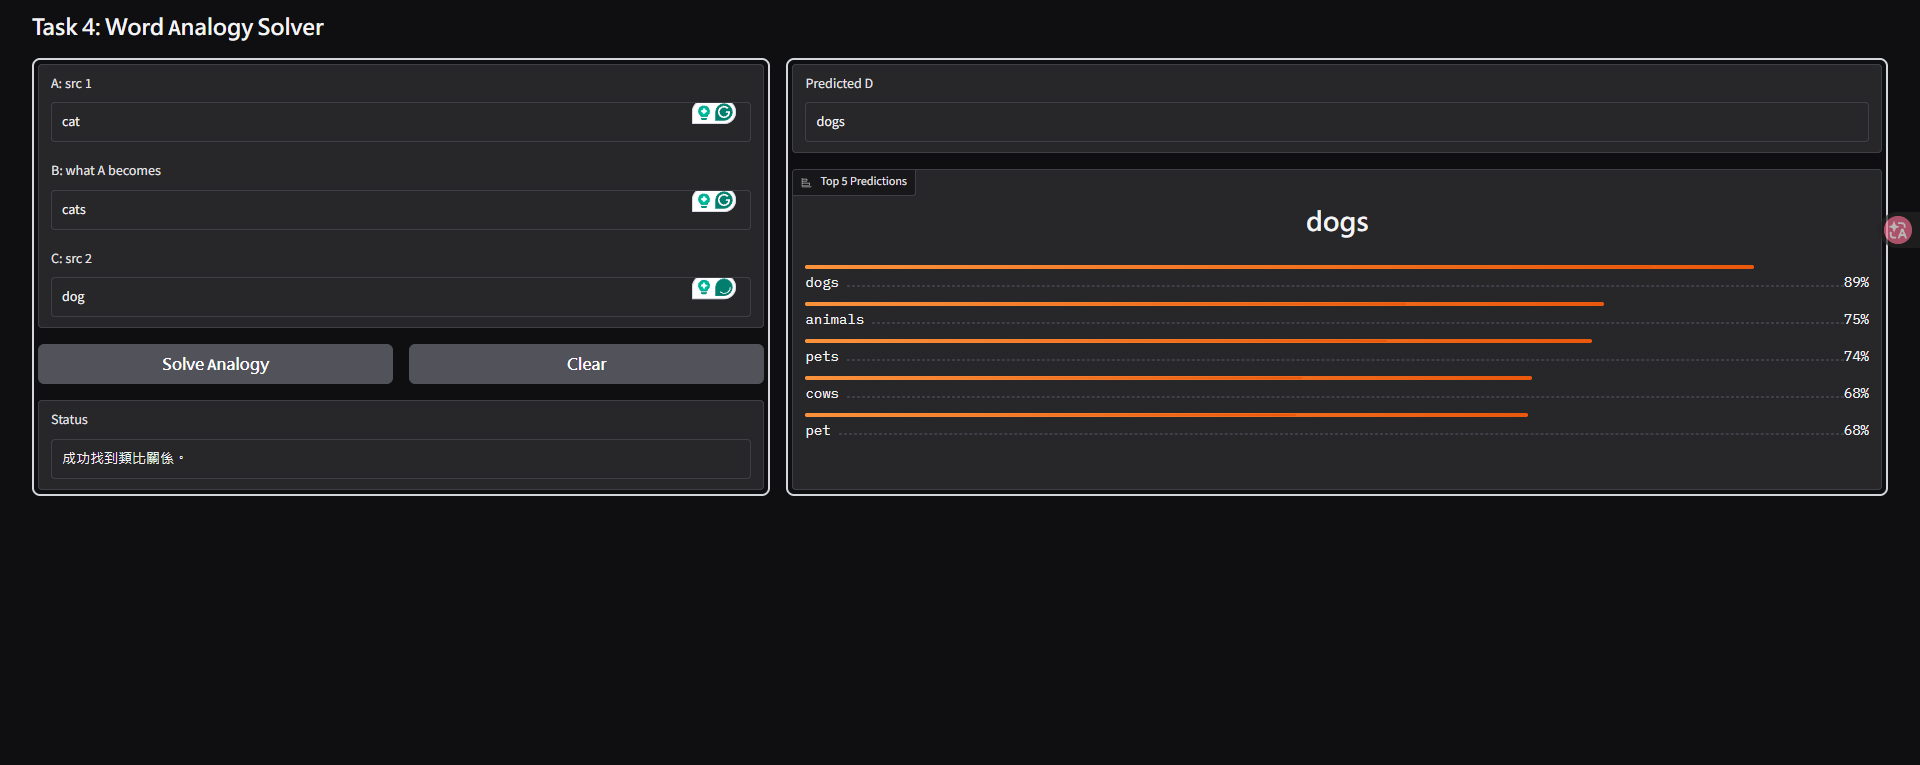
*圖 5(單複數類比, 成功)：`cat : cats :: dog : ?` 預測 `dogs`(89%), Top 5 為 dogs / animals / pets / cows / pet, 複數形與動物類詞主導, 分數高代表方向明確. *

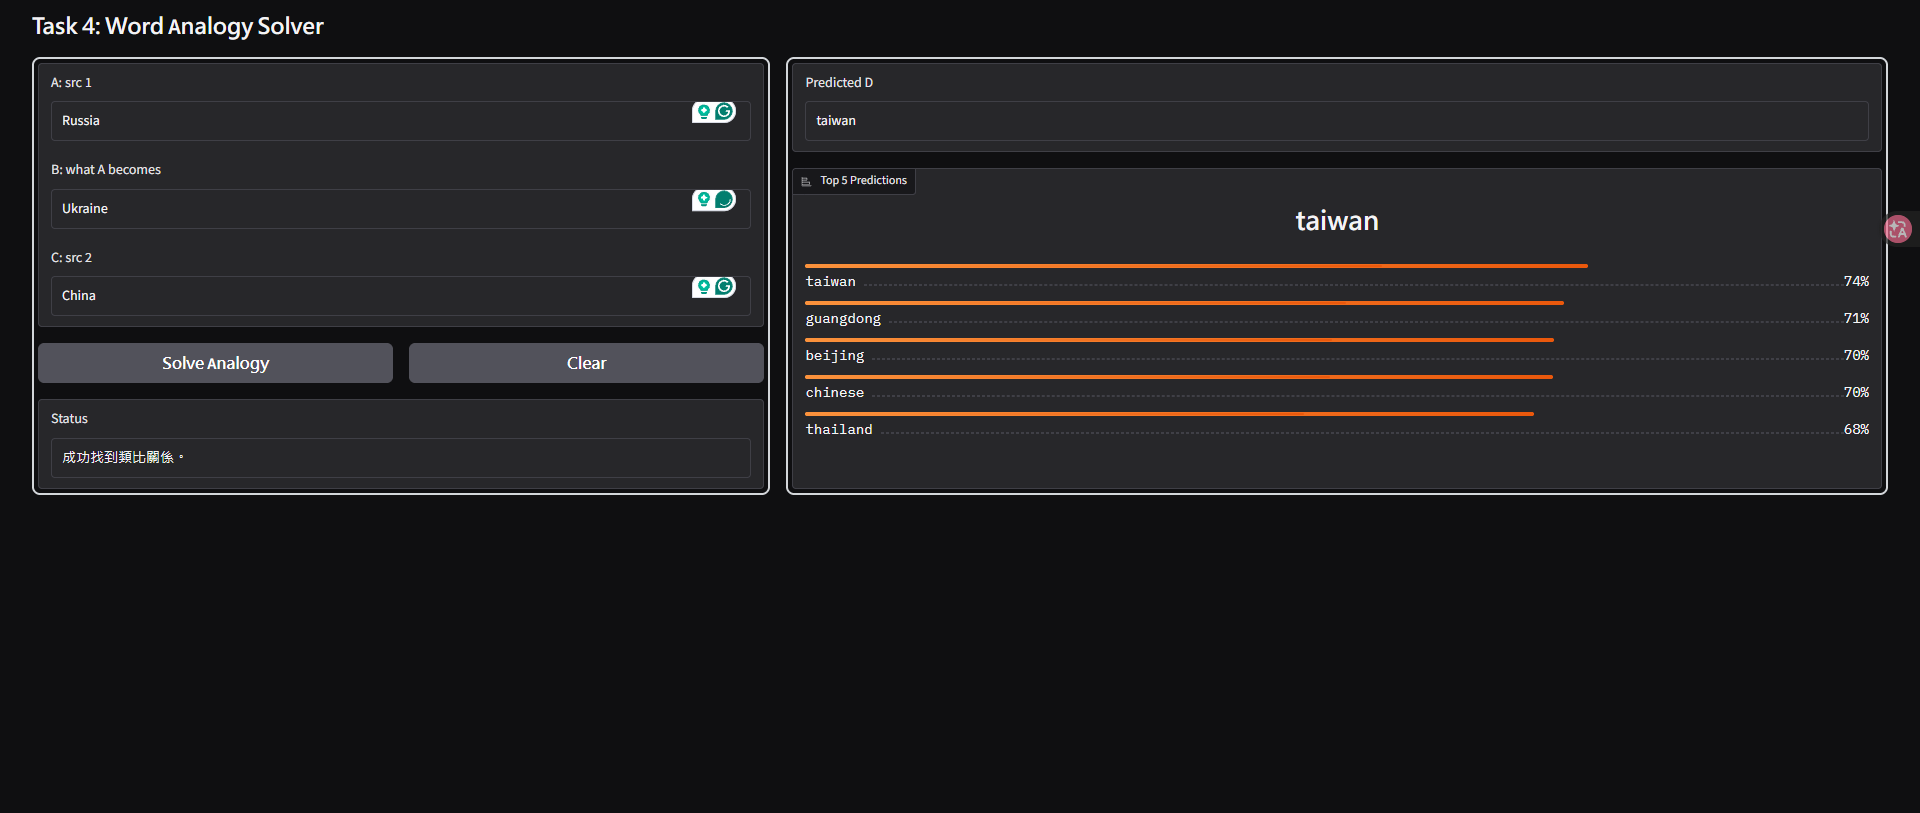
*圖 6(地緣政治類比, 成功)：`Russia : Ukraine :: China : ?` 預測 `taiwan`(74%), Top 5 為 taiwan / guangdong / beijing / chinese / thailand, 皆為中國或亞洲地緣相關詞, 顯示向量方向一致. *

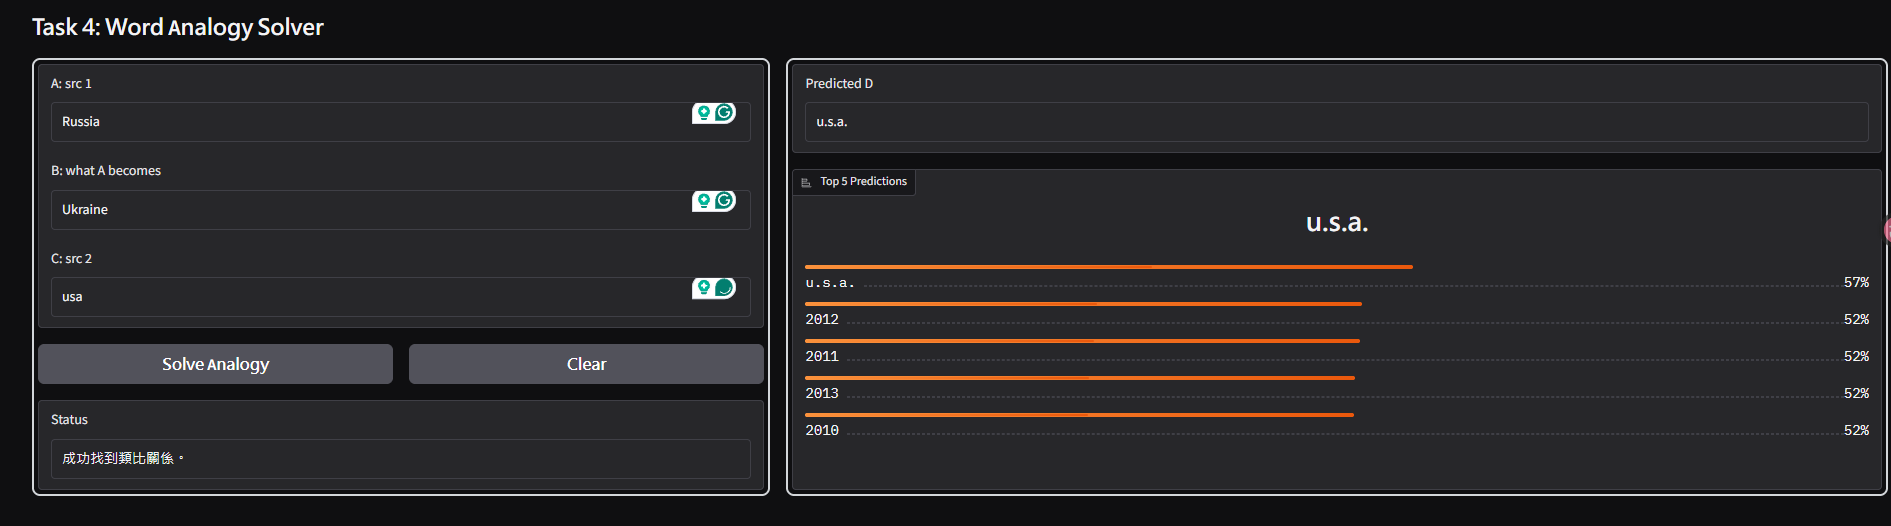
*圖 7(失敗案例)：`Russia : Ukraine :: usa : ?` 預測 `u.s.a.`(57%). 失敗原因：`usa` 與 `u.s.a.` 在語料中幾乎同義, 最近鄰就是 C 自己, 形成自我指涉而非真正的類比推理；且 Top 5 出現 2011–2019 等年份雜訊, 最高分僅 57%, 顯示目標向量方向不確定. *

## Task 5: Autoencoder and VAE Lab


**目標**: 在 MNIST 手寫數字上訓練一個 autoencoder(AE), 然後做一個含四個獨立介面的 Gradio app, 讓使用者探索模型學到了什麼. 若要拿滿分, 再加上 variational autoencoder(VAE)與第五個介面, 走訪它的 latent space. 

### 待辦清單(訓練, 在 app 之前)
- [x] AE 將 28×28 灰階數字編碼成最多 16 個數字的 latent, 再解碼回影像. 
- [x] 確認訓練用的像素範圍(0–255 或 0–1), app 的每個輸入都轉成相同範圍, 輸出再轉回顯示. 
- [x] 在啟動 app 前完成訓練, 不要在 Gradio 函式內訓練. 

### 待辦清單(app：四個介面)
- [x] Reconstruct：上傳數字圖, 函式內 resize 到 28×28 並正規化；顯示 latent、重建與 MSE(latent 用四捨五入的數字). 
- [x] Draw：從 `gr.ImageEditor` 取 composite, 轉灰階、偵測背景色並視需要反轉, 再 resize 與重建；顯示模型實際收到的 28×28 影像與重建. 
- [x] Noise：用 slider 設定 σ, 加入高斯雜訊並 clip；顯示乾淨輸入、雜訊輸入與雜訊重建. 
- [x] Garbage in：一個影像輸入, 輸出重建與 MSE；對一個真數字與至少三個非數字各跑一次並截圖, 並回答兩個問題(模型對非數字輸出什麼、為何；MSE 能否判斷是否為數字). 

### 待辦清單(VAE, 滿分 6 分)
- [x] 訓練 VAE(latent ≤ 16), encoder 輸出 μ 與 log σ², 用 reparameterisation trick 取樣 z, loss 加入 KL 項；若改編範例程式碼要在註解引用. 
- [x] Reconstruct 可選 AE 或 VAE；VAE 要分別顯示 μ 與取樣的 z. 
- [x] Interpolate(第五個介面)：上傳兩張數字 X、Y, 用 VAE 編碼後在 latent 間直線插值(端點恰為 X、Y), 解碼成影像路徑；說明插值的是 μ 還是 z 及原因, 並描述中間影像. 

**AI use**: 使用 GitHub Copilot 協助解讀規格、查詢 PyTorch/torchvision API(`DataLoader`、`transforms.ToTensor`、`ToPILImage`)、`gr.ImageEditor` 的 composite 取法與 `gr.Slider` 的 `change` 事件、以及除錯(Gradio 6 的 `css` 要放在 `launch()`、VAE 的 posterior collapse 需把重建 loss 改成 `F.mse_loss(..., reduction="sum") / x.size(0)` 才不會被 KL 項壓過)；`Autoencoder`/`VAE` 的網路結構、reparameterisation trick、`vae_loss` 的 KL 推導、五個介面的版面與互動邏輯、以及插值用 μ 而非取樣 z 的設計決定, 是我理解 AI 給的範例後自行改寫與調整的. 

### code

#### Training AE

In [323]:
from torchvision import transforms
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import datasets
from torch.utils.data import DataLoader

In [324]:
t5_transform = transforms.ToTensor()   # PIL 影像 (0–255) → tensor (0.0–1.0)

##### step 1: Load MNIST dataset and preprocess

In [325]:
t5_train_dataset = datasets.MNIST(
    root="./data", train=True, download=True, transform=t5_transform
)
t5_test_dataset = datasets.MNIST(
    root="./data", train=False, download=True, transform=t5_transform
)

t5_train_loader = DataLoader(t5_train_dataset, batch_size=128, shuffle=True)
t5_test_loader = DataLoader(t5_test_dataset, batch_size=128, shuffle=False)

In [326]:
images, labels = next(iter(t5_train_loader))
print(images.shape)   # 應該是 torch.Size([128, 1, 28, 28])
print(images.min(), images.max())   # 應該在 0~1 之間

torch.Size([128, 1, 28, 28])
tensor(0.) tensor(1.)


##### step 2: Define Autoencoder model

In [327]:
class Autoencoder(nn.Module):
    def __init__(self, latent_dim=16):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Flatten(),
            nn.Linear(784, 128),
            nn.ReLU(),
            nn.Linear(128, latent_dim),
        )
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 784),
            nn.Sigmoid(),  # 將輸出壓縮到 0–1 範圍
        )

    def forward(self, x):
        z = self.encoder(x)
        x_hat = self.decoder(z)
        return x_hat.view(-1, 1, 28, 28)  # 重塑回 (batch_size, 1, 28, 28)

In [ ]:
ae_model = Autoencoder()
x = torch.randn(4, 1, 28, 28)   # 假裝 4 張圖
out = ae_model(x)
print(out.shape)   # 應該是 torch.Size([4, 1, 28, 28])
print(out.min(), out.max())   # 應該在 0~1 之間(因為有 Sigmoid)

torch.Size([4, 1, 28, 28])
tensor(0.3955, grad_fn=<MinBackward1>) tensor(0.5766, grad_fn=<MaxBackward1>)


##### step 3: Loss Optimizer and Training Loop

In [ ]:
optimizer = torch.optim.Adam(ae_model.parameters(), lr=1e-3)

EPOCHS = 10

try:
    ae_model.load_state_dict(torch.load("ae_mnist.pth"))
    print("已載入既有的 ae_mnist.pth, 跳過訓練. ")
except FileNotFoundError:
    print("找不到 ae_mnist.pth, 將重新訓練模型. ")
    for epoch in range(EPOCHS):
        ae_model.train()
        total_loss = 0.0
        for images, _ in t5_train_loader:
            optimizer.zero_grad()
            outputs = ae_model(images)            # 前向傳播：計算重建
            loss = F.mse_loss(outputs, images)  # 算 loss
            loss.backward()
            optimizer.step()
            total_loss += loss.item() * images.size(0)
        avg_loss = total_loss / len(t5_train_dataset)
        print(f"Epoch {epoch+1}/{EPOCHS}  loss = {avg_loss:.4f}")

已載入既有的 ae_mnist.pth，跳過訓練。


In [330]:
torch.save(ae_model.state_dict(), "ae_mnist.pth")

Test MSE: 0.0134


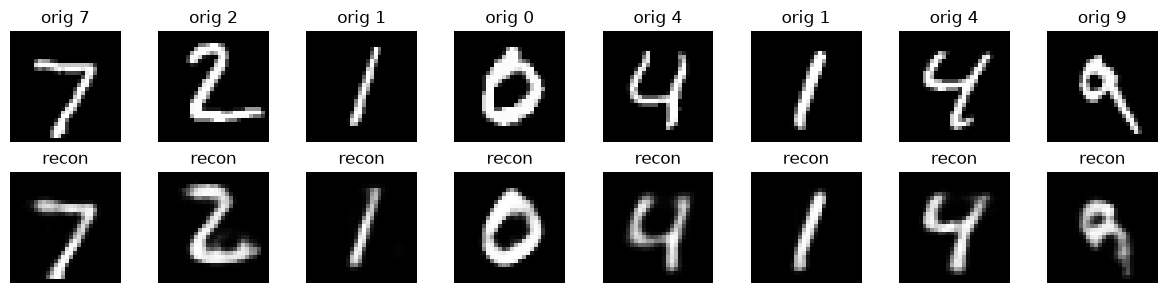

In [331]:
import matplotlib.pyplot as plt

images, labels = next(iter(t5_test_loader))
ae_model.eval()
with torch.no_grad():
    reconstructions = ae_model(images)

mse = F.mse_loss(reconstructions, images)
print(f"Test MSE: {mse.item():.4f}")

n = 8   # 看 8 張
fig, axes = plt.subplots(2, n, figsize=(n*1.5, 3))
for i in range(n):
    axes[0, i].imshow(images[i].squeeze(0), cmap="gray")
    axes[0, i].set_title(f"orig {labels[i].item()}")
    axes[0, i].axis("off")
    axes[1, i].imshow(reconstructions[i].squeeze(0), cmap="gray")
    axes[1, i].set_title("recon")
    axes[1, i].axis("off")
plt.tight_layout()
plt.show()

#### Training VAE

##### Step 1: Define VAE Model

In [ ]:
class VAE(nn.Module):
    def __init__(self, latent_dim=16):
        super().__init__()
        self.latent_dim = latent_dim

        # encoder：輸出 2 * latent_dim(前半 mu, 後半 logvar)
        self.encoder = nn.Sequential(
            nn.Flatten(),
            nn.Linear(784, 128),
            nn.ReLU(),
            nn.Linear(128, 2 * latent_dim),   # 2 * latent_dim
        )

        # decoder：
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 784),
            nn.Sigmoid(),
        )

    def encode(self, x):
        """回傳 (mu, logvar). """
        h = self.encoder(x)
        mu, logvar = torch.chunk(h, 2, dim=-1)
        return mu, logvar

    def reparameterise(self, mu, logvar):
        """從 N(mu, sigma^2) 取樣 z, 並回傳梯度. """
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + std * eps

    def decode(self, z):
        """把 z 解碼回影像. """
        x_hat = self.decoder(z)
        return x_hat.view(-1, 1, 28, 28)

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterise(mu, logvar)
        x_hat = self.decode(z)
        return x_hat, mu, logvar



##### Step 2: VAE Loss Function

In [ ]:
def vae_loss(x_hat, x, mu, logvar):
    # reduction="sum" 後除以 batch size, 讓 recon 與 kl 同尺度(都是 per-sample sum)
    recon = F.mse_loss(x_hat, x, reduction="sum") / x.size(0)
    kl = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    kl = kl / x.size(0)
    return recon + kl

##### Step 3: Train VAE Model

In [ ]:
vae_model = VAE()
vae_optimizer = torch.optim.Adam(vae_model.parameters(), lr=1e-3)
VAE_EPOCHS = 10
try:
    vae_model.load_state_dict(torch.load("vae_mnist.pth"))
    print("已載入既有的 vae_mnist.pth, 跳過訓練. ")
except FileNotFoundError:
    print("找不到 vae_mnist.pth, 將重新訓練 VAE. ")
    for epoch in range(VAE_EPOCHS):
        vae_model.train()
        total_loss = 0.0
        for images, _ in t5_train_loader:
            vae_optimizer.zero_grad()
            x_hat, mu, logvar = cast(
                tuple[torch.Tensor, torch.Tensor, torch.Tensor],
                vae_model(images)
                )
            loss = vae_loss(x_hat, images, mu, logvar)
            loss.backward()
            vae_optimizer.step()
            total_loss += loss.item() * images.size(0)
        avg_loss = total_loss / len(t5_train_dataset)
        print(f"Epoch {epoch+1}/{VAE_EPOCHS}  loss = {avg_loss:.4f}")

已載入既有的 vae_mnist.pth，跳過訓練。


In [335]:
torch.save(vae_model.state_dict(), "vae_mnist.pth")

##### Step 4: Validate VAE Model

VAE Test MSE: 0.0270


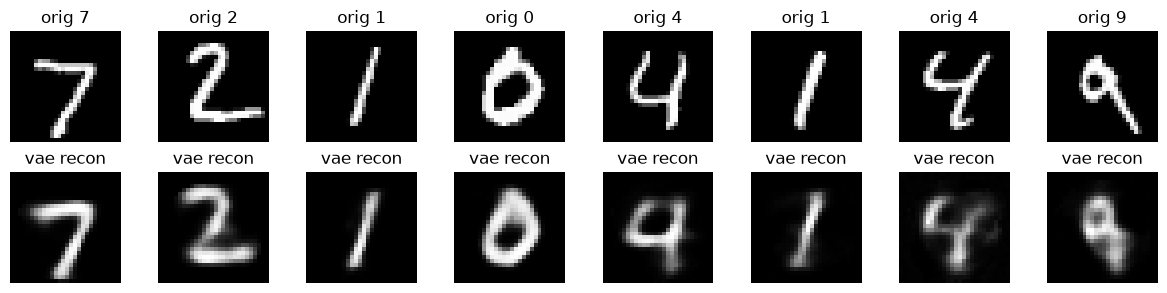

In [336]:
images, labels = next(iter(t5_test_loader))
vae_model.eval()
with torch.no_grad():
    vae_recon, vae_mu, vae_logvar = cast(
        tuple[torch.Tensor, torch.Tensor, torch.Tensor],
        vae_model(images)
    )

print(f"VAE Test MSE: {F.mse_loss(vae_recon, images).item():.4f}")

n = 8
fig, axes = plt.subplots(2, n, figsize=(n*1.5, 3))
for i in range(n):
    axes[0, i].imshow(images[i].squeeze(0), cmap="gray")
    axes[0, i].set_title(f"orig {labels[i].item()}")
    axes[0, i].axis("off")
    axes[1, i].imshow(vae_recon[i].squeeze(0), cmap="gray")
    axes[1, i].set_title("vae recon")
    axes[1, i].axis("off")
plt.tight_layout()
plt.show()


#### App

In [337]:
T5_CSS = """
.equal-height-row {
    align-items: stretch;
}
.equal-height-row > .cell-box {
    height: auto;
    display: flex;
    flex-direction: column;
}
.cell-box {
    border: 2px solid #d3d6da;
    border-radius: 8px;
    padding: 4px;
    height: 100%;
}
div.block.svelte-1plpy97.auto-margin:not(.padded) {
    padding: 30px 0;
}
.flex-height-avg > * {
    flex-grow: 1;
    height: fit-content;
}
"""

##### Interface 1: Reconstruct

In [ ]:
def build_reconstruct_tab():
    def reconstruct_image_ae(image):
        """用 AE 重建, 回傳 (latent, mu, z, 重建圖, mse, 狀態). """
        image = image.convert("L").resize((28, 28))
        image_tensor = t5_transform(image).unsqueeze(0)  # (1, 1, 28, 28)

        ae_model.eval()
        with torch.no_grad():
            latent = ae_model.encoder(image_tensor)          # (1, 16)
            reconstructed_flat = ae_model.decoder(latent)        # (1, 784)
            reconstructed_tensor = reconstructed_flat.view(-1, 1, 28, 28)

        latent_list = ", ".join(f"{v:.2f}" for v in latent.squeeze(0).tolist())
        reconstructed_image = transforms.ToPILImage()(reconstructed_tensor.squeeze(0))
        mse_text = f"{F.mse_loss(reconstructed_tensor, image_tensor).item():.4f}"

        return latent_list, "(AE 沒有 μ)", "(AE 沒有取樣 z)", reconstructed_image, mse_text, "AE 重建完成！"

    def reconstruct_image_vae(image):
        """用 VAE 重建, 回傳 (latent, mu, z, 重建圖, mse, 狀態). """
        image = image.convert("L").resize((28, 28))
        image_tensor = t5_transform(image).unsqueeze(0)  # (1, 1, 28, 28)

        vae_model.eval()
        with torch.no_grad():
            mu, logvar = vae_model.encode(image_tensor)
            z = vae_model.reparameterise(mu, logvar)
            reconstructed_tensor = vae_model.decode(z)

        mu_text = ", ".join(f"{v:.2f}" for v in mu.squeeze(0).tolist())
        z_text = ", ".join(f"{v:.2f}" for v in z.squeeze(0).tolist())
        reconstructed_image = transforms.ToPILImage()(reconstructed_tensor.squeeze(0))
        mse_text = f"{F.mse_loss(reconstructed_tensor, image_tensor).item():.4f}"

        return "(VAE 的 latent 是分布, 請看 μ 與 z)", mu_text, z_text, reconstructed_image, mse_text, "VAE 重建完成！"

    def reconstruct_image(image, model_choice):
        """Router：依 model_choice 分派到 AE 或 VAE. """
        if image is None:
            return None, None, None, None, None, "請先上傳一張手寫數字圖片. "

        if model_choice == "AE":
            return reconstruct_image_ae(image)
        return reconstruct_image_vae(image)

    with gr.Tab("Reconstruct"):
        gr.Markdown("## Reconstruct")

        with gr.Row(elem_classes="equal-height-row"):
            with gr.Column(scale=1, elem_classes="cell-box"):
                model_choice = gr.Radio(
                    choices=["AE", "VAE"],
                    value="AE",
                    label="Model",
                )
                upload = gr.Image(
                    label="上傳一張手寫數字圖片 (最好 28x28)",
                    type="pil",
                    image_mode="L",  # 灰階
                    sources=["upload"],
                )
                predict_btn = gr.Button("重建圖片")
                status = gr.Textbox(label="狀態", value="請上傳一張手寫數字圖片並按「重建圖片」", interactive=False)

            with gr.Column(scale=2, elem_classes="cell-box"):
                latent = gr.Textbox(label="潛在向量 (Latent Vector)", interactive=False)
                vae_mu = gr.Textbox(label="VAE only: μ", interactive=False)
                vae_sampled_z = gr.Textbox(label="VAE only: Sampled z", interactive=False)

            with gr.Column(scale=1, elem_classes="cell-box"):
                reconstructed = gr.Image(label="重建結果", type="pil")
                mse_textbox = gr.Textbox(label="MSE", interactive=False)

        predict_btn.click(
            reconstruct_image,
            inputs=[upload, model_choice],
            outputs=[latent, vae_mu, vae_sampled_z, reconstructed, mse_textbox, status],
        )

##### Interface 2: Draw

In [ ]:
import numpy as np
from PIL import Image, ImageOps


def build_draw_tab():
    def is_white_background(img: Image.Image, k: int = 5) -> bool:
        """ """
        arr = np.array(img)
        h, w = arr.shape
        if h < k or w < k:  # 純保險
            return False
        # 取四個角落的像素值
        corners = [
            arr[:k, :k].mean(),  # 左上
            arr[:k, -k:].mean(),  # 右上
            arr[-k:, :k].mean(),  # 左下
            arr[-k:, -k:].mean(),  # 右下
        ]
        return float(np.mean(corners)) > 127  # 平均值大於 127 就認為是白色背景

    def preprocess_drawing(composite: Image.Image) -> Image.Image:
        """ """
        if composite.mode == "RGBA":
            bg = Image.new("RGB", composite.size, (255, 255, 255))
            bg.paste(composite, mask=composite.split()[3])  # 3 is the alpha channel
            composite = bg

        img = composite.convert("L")  # 灰階

        if is_white_background(img):
            img = ImageOps.invert(img)

        img = img.resize((28, 28))

        return img

    def draw_and_reconstruct(editor_value):
        if editor_value is None:
            return None, None, "請先畫一個數字再按「重建圖片」. "

        composite = editor_value.get("composite")
        if composite is None:
            return None, None, "畫布上沒有任何內容, 請畫一個數字再按「重建圖片」. "

        processed = preprocess_drawing(composite)

        image_tensor = t5_transform(processed).unsqueeze(0)  # shape: (1, 1, 28, 28)

        ae_model.eval()
        with torch.no_grad():
            latent = ae_model.encoder(image_tensor)  # (1, 16)
            reconstructed_flat = ae_model.decoder(latent)  # (1, 784)
            reconstructed_tensor = reconstructed_flat.view(-1, 1, 28, 28)

        reconstructed_image = transforms.ToPILImage()(reconstructed_tensor.squeeze(0))

        return processed, reconstructed_image, "重建完成！"

    with gr.Tab("Draw"):
        gr.Markdown("## Draw")

        with gr.Row(elem_classes="equal-height-row"):
            with gr.Column(scale=1, elem_classes="cell-box"):
                editor = gr.ImageEditor(
                    label="畫一個數字",
                    type="pil",
                    image_mode="L",
                    sources=["upload", "webcam", "clipboard"],
                    brush=gr.Brush(colors=["#000000"], default_size=20),
                    canvas_size=(280, 280),
                    fixed_canvas=True,
                )

                draw_btn = gr.Button("重建圖片")
                clear_btn = gr.Button("清除畫布")
                status = gr.Textbox(
                    label="狀態",
                    value="請畫一個數字並按「重建圖片」",
                    interactive=False,
                )
            with gr.Column(scale=1, elem_classes="cell-box flex-height-avg"):
                model_input = gr.Image(label="輸入圖片", type="pil")
                reconstructed = gr.Image(label="重建結果", type="pil")

        draw_btn.click(
            draw_and_reconstruct,
            inputs=[editor],
            outputs=[model_input, reconstructed, status],
        )

        clear_btn.click(
            lambda: (None, None, None, "請畫一個數字並按「重建圖片」"),
            inputs=[],
            outputs=[editor, model_input, reconstructed, status],
        )

##### Interface 3: Noise

In [ ]:
def build_noise_tab():

    def add_noise_to_image_and_reconstruct(image_pil, noise_level_sigma):
        if image_pil is None:
            return None, None, None, "請先選擇一張測試集圖片再調整噪音強度. "

        image_pil = image_pil.resize((28, 28))
        image_tensor = t5_transform(image_pil).unsqueeze(0)  # shape: (1, 1, 28, 28)

        noise = torch.randn_like(image_tensor) * noise_level_sigma
        noisy_image_tensor = (image_tensor + noise).clamp(0.0, 1.0) # clamp to [0, 1]

        ae_model.eval()
        with torch.no_grad():
            recon_image_tensor = ae_model(noisy_image_tensor)

        noisy_image_pil = transforms.ToPILImage()(noisy_image_tensor.squeeze(0))
        recon_image_pil = transforms.ToPILImage()(recon_image_tensor.squeeze(0))

        return image_pil, noisy_image_pil, recon_image_pil, f"加噪音(σ: {noise_level_sigma})並重建完成！"

    def load_random_test_image():
        idx = cast(int, torch.randint(len(t5_test_dataset), (1,)).item())
        image, label = t5_test_dataset[idx] # (1, 28, 28), 0-1
        image_pil = transforms.ToPILImage()(image)
        return image_pil, f"隨機選擇測試集圖片 (label: {label})"


    with gr.Tab("Noise"):
        gr.Markdown("## Noise")
        with gr.Row(elem_classes="equal-height-row"):
            with gr.Column(scale=1, elem_classes="cell-box"):
                selected_image = gr.Image(label="選擇一張測試集圖片", type="pil", image_mode="L")
                random_btn = gr.Button("隨機選一張")
                status = gr.Textbox(
                    label="狀態",
                    value="請選擇一張測試集圖片, 調整噪音強度, 然後按「加噪音」",
                    interactive=False,
                )


            with gr.Column(scale=4, elem_classes="cell-box"):
                noise_slider = gr.Slider(
                    label="噪音強度",
                    minimum=0.0, maximum=1.0, step=0.01, value=0.0,
                )
                with gr.Row(elem_classes="align-items-stretch flex-height-avg"):
                    clean_image = gr.Image(label="原始圖片", type="pil")
                    noisy_image = gr.Image(label="加噪音後的圖片", type="pil")
                    reconstructed = gr.Image(label="重建結果", type="pil")

        random_btn.click(
            load_random_test_image,
            inputs=[],
            outputs=[selected_image, status],
        )

        selected_image.change(
            add_noise_to_image_and_reconstruct,
            inputs=[selected_image, noise_slider],
            outputs=[clean_image, noisy_image, reconstructed, status]
        )

        noise_slider.change(
            add_noise_to_image_and_reconstruct,
            inputs=[selected_image, noise_slider],
            outputs=[clean_image, noisy_image, reconstructed, status]
        )

##### Interface 4: Garbage in

In [ ]:
def build_garbage_in_tab():
    def reconstruct_image(image):
        if image is None:
            return None, None, "請先上傳一張手寫數字圖片. "

        image = image.convert("L").resize((28, 28))  # 調整為 28x28

        # 將 PIL 圖片轉為 tensor, 並加 batch 維度
        image_tensor = t5_transform(image).unsqueeze(0)  # shape: (1, 1, 28, 28)

        ae_model.eval()
        with torch.no_grad():
            latent = ae_model.encoder(image_tensor)          # (1, 16)
            reconstructed_flat = ae_model.decoder(latent)        # (1, 784)
            reconstructed_tensor = reconstructed_flat.view(-1, 1, 28, 28)

        # 4. 輸出
        reconstructed_image = transforms.ToPILImage()(reconstructed_tensor.squeeze(0))
        mse_value = F.mse_loss(reconstructed_tensor, image_tensor).item()
        mse_text = f"{mse_value:.4f}"

        return reconstructed_image, mse_text, "重建完成！"

    with gr.Tab("Garbage in"):
        gr.Markdown("## Garbage in")

        with gr.Row(elem_classes="equal-height-row"):
            with gr.Column(scale=1, elem_classes="cell-box"):
                upload = gr.Image(
                    label="上傳任何一張圖片",
                    type="pil",
                    image_mode="L",  # 灰階
                    sources=["upload"],
                )
                predict_btn = gr.Button("重建圖片")
                status = gr.Textbox(label="狀態", value="請上傳一張手寫數字圖片並按「重建圖片」", interactive=False)

            with gr.Column(scale=2, elem_classes="cell-box flex-height-avg"):
                reconstructed = gr.Image(label="重建結果", type="pil")

            with gr.Column(scale=1, elem_classes="cell-box"):
                mse_textbox = gr.Textbox(label="MSE", interactive=False)

        predict_btn.click(
            reconstruct_image,
            inputs=[upload],
            outputs=[reconstructed, mse_textbox, status],
        )

##### Interface 5: Interpolate (VAE only)

Q1. Say whether you interpolate μ or the sampled z, and why.

用 μ 做插值, 而不是取樣的 z. 因為 μ 是編碼器輸出的確定性(deterministic)向量, 同一張輸入圖每次都會得到相同的 μ, 所以插值路徑可重現、端點也精確等於 X 與 Y 的重建. 若改用取樣的 z, 每次執行都會因隨機取樣而得到不同的路徑, 端點也不會穩定對應到 X、Y. 


Q2. In a few sentences, describe the in-between images: do they look like real digits, and why do you think so?

in-between images大多看起來像真的數字. 因為 VAE 的 latent 空間經過 KL 正則化後是連續且平滑的, 兩點之間的直線會落在"有數字意義"的區域內, 所以解碼出來的圖形是逐漸變形的數字, 而不是雜訊. 不過在最中間的那幾張圖, 圖形處於兩個數字之間的模糊過渡態 (例如 6 與 7 之間會短暫出現像 8 or 9 的形狀), 看起來略為模糊、筆畫不完整, 因為該處的 latent 點落在兩個數字流形之間, 模型沒有學過這種混合的樣本. 整體而言, 路徑是平滑且可辨識的, 證明 VAE 學到的 latent 空間具有連續性. 


In [ ]:
# 縮圖固定大小(px)
T5_I5_THUMB_SIZE = 84
# 縮圖之間的間距(px)
T5_I5_GAP = 8

T5_I5_GALLERY_CSS = f"""
#gallery .grid-wrap {{
    height: 100%
    flex-grow: 1
    overflow-y: auto
}}
#gallery .grid-container {{
    grid-template-columns: repeat(auto-fill, {T5_I5_THUMB_SIZE}px) !important;
    gap: {T5_I5_GAP}px !important;
    justify-content: center !important;
}}
#gallery .gallery-item,
#gallery .thumbnail-item {{
    width: {T5_I5_THUMB_SIZE}px !important;
    height: {T5_I5_THUMB_SIZE}px !important;
}}
"""

In [ ]:
def build_interpolate_vae_tab():
    def interpolate(x_tensor, y_tensor, alpha):
        vae_model.eval()
        with torch.no_grad():
            # 用 μ(而非取樣的 z)做插值, 因為 μ 是確定性的, 插值結果才可重現
            mu_x, _ = vae_model.encode(x_tensor)
            mu_y, _ = vae_model.encode(y_tensor)

            # 線性插值：alpha=0 得到 X, alpha=1 得到 Y
            mu_interp = (1 - alpha) * mu_x + alpha * mu_y

            # 解碼插值後的 latent
            interp_tensor = vae_model.decode(mu_interp)

        interp_image = transforms.ToPILImage()(interp_tensor.squeeze(0))

        return interp_image

    def x_steps2_y(image_x, image_y, steps):
        if image_x is None or image_y is None:
            return [], "請先上傳兩張手寫數字圖片(X 與 Y). "

        # 兩張圖都轉成 (1, 1, 28, 28) 的 tensor
        x_pil = image_x.convert("L").resize((28, 28))
        y_pil = image_y.convert("L").resize((28, 28))
        x_tensor = t5_transform(x_pil).unsqueeze(0)
        y_tensor = t5_transform(y_pil).unsqueeze(0)

        # 產生插值的 alpha 值(steps 張圖, 端點分別為 0 與 1)
        alphas = np.linspace(0, 1, steps)
        images = [interpolate(x_tensor, y_tensor, alpha) for alpha in alphas]

        # 驗證端點：第一張應等於 X 的重建, 最後一張應等於 Y 的重建
        vae_model.eval()
        with torch.no_grad():
            mu_x, _ = vae_model.encode(x_tensor)
            mu_y, _ = vae_model.encode(y_tensor)
            recon_x = transforms.ToPILImage()(vae_model.decode(mu_x).squeeze(0))
            recon_y = transforms.ToPILImage()(vae_model.decode(mu_y).squeeze(0))

        first_ok = np.allclose(np.asarray(images[0]), np.asarray(recon_x))
        last_ok = np.allclose(np.asarray(images[-1]), np.asarray(recon_y))
        check = "端點驗證通過" if (first_ok and last_ok) else "端點驗證失敗"

        status = (
            f"共 {steps} 步：第 1 張 = X 的重建, 第 {steps} 張 = Y 的重建"
            f"({check})"
        )
        return images, status

    with gr.Tab("Interpolate (VAE)"):
        gr.Markdown("## Interpolate (VAE)")

        with gr.Row(elem_classes="equal-height-row"):
            with gr.Column(scale=1, elem_classes="cell-box"):
                image_x = gr.Image(
                    label="圖片 X(路徑起點)",
                    type="pil",
                    image_mode="L",
                    sources=["upload"],
                )
                image_y = gr.Image(
                    label="圖片 Y(路徑終點)",
                    type="pil",
                    image_mode="L",
                    sources=["upload"],
                )
                steps_slider = gr.Slider(
                    label="步數 (Steps)",
                    minimum=2,
                    maximum=20,
                    step=1,
                    value=7,
                )
                status = gr.Textbox(
                    label="狀態",
                    value="請上傳兩張圖片, 然後拖動滑桿看插值結果. ",
                    interactive=False,
                )

            with gr.Column(scale=3, elem_classes="cell-box"):
                with gr.Row(elem_classes="align-items-stretch flex-height-avg"):
                    path_gallery = gr.Gallery(
                        label="VAE path: X to Y",
                        show_label=False,
                        elem_id="gallery",
                    )

        steps_slider.change(
            x_steps2_y,
            inputs=[image_x, image_y, steps_slider],
            outputs=[path_gallery, status],
        )
        image_x.change(
            x_steps2_y,
            inputs=[image_x, image_y, steps_slider],
            outputs=[path_gallery, status],
        )
        image_y.change(
            x_steps2_y,
            inputs=[image_x, image_y, steps_slider],
            outputs=[path_gallery, status],
        )

##### Demo definition and launch

In [373]:
with gr.Blocks(title="AE / VAE Lab") as t5_demo:
    gr.Markdown("## Task 5: Autoencoder / VAE Lab")
    with gr.Tabs():
      build_reconstruct_tab()
      build_draw_tab()
      build_noise_tab()
      build_garbage_in_tab()
      build_interpolate_vae_tab()

t5_demo.launch(css=T5_CSS + T5_I5_GALLERY_CSS)

* Running on local URL:  http://127.0.0.1:7894
* To create a public link, set `share=True` in `launch()`.


### 測試以及截圖

AE:
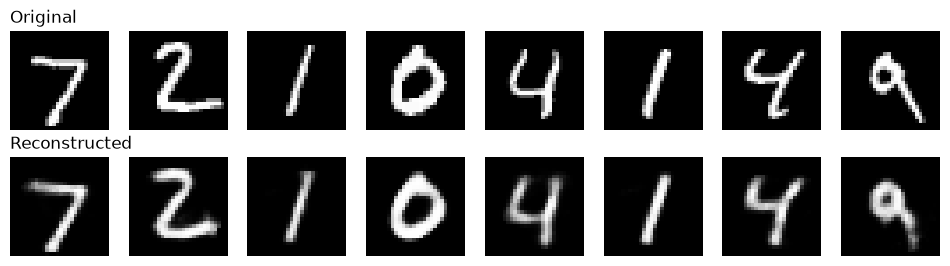
AE Test MSE: 0.0134

VAE:
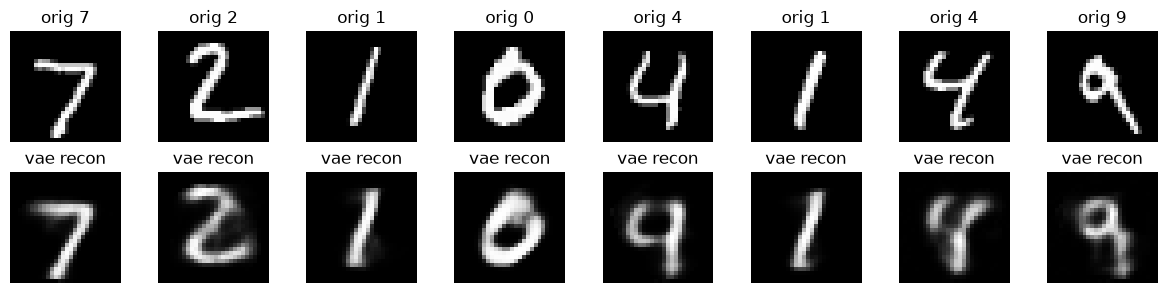
VAE Test MSE: 0.0266

##### Interface 1: Reconstruct
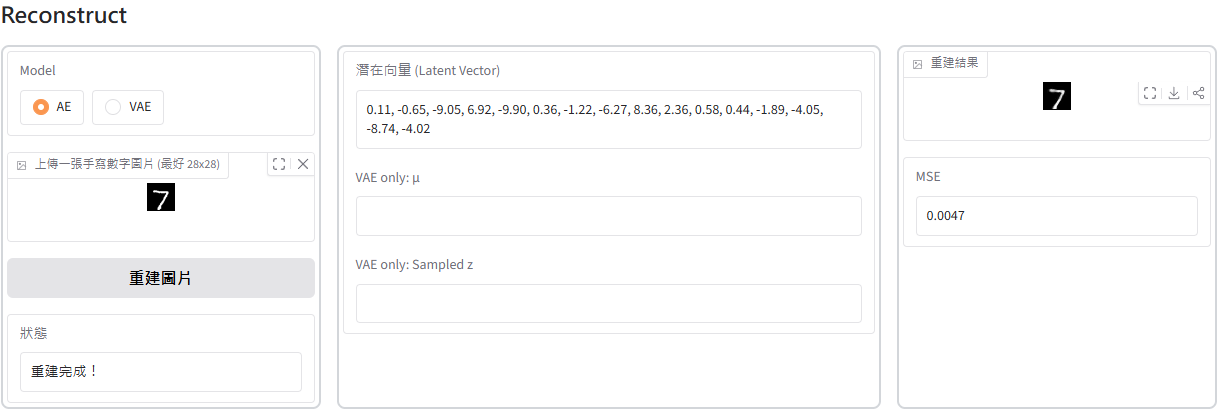
*AE 模式重建數字「7」：顯示 16 維 latent 向量, 重建結果幾乎完美, MSE = 0.0047. *

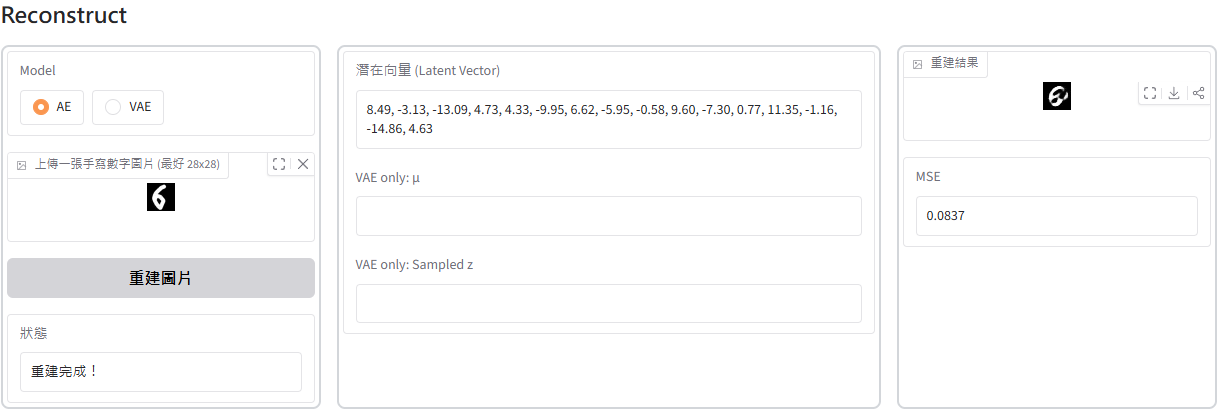
*AE 模式重建數字「6」：顯示 16 維 latent 向量, 重建結果正確, MSE = 0.0837. *

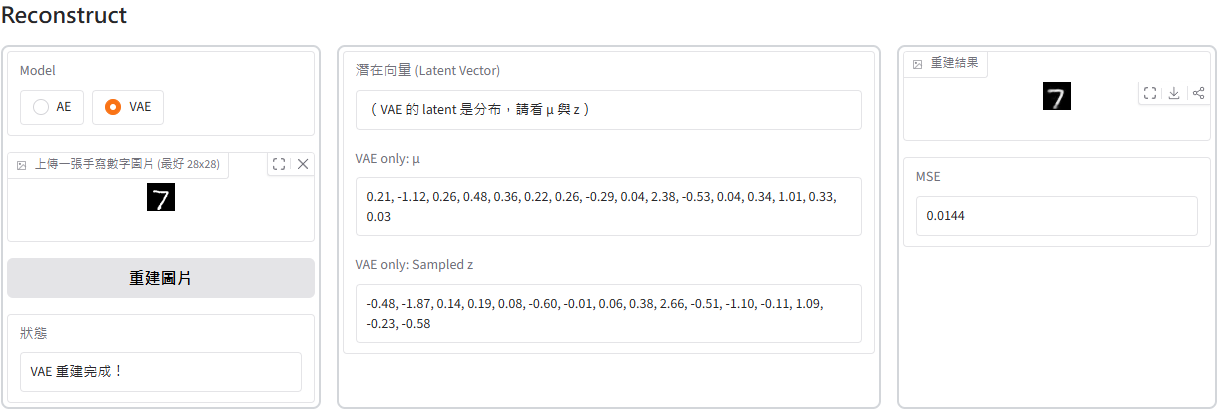
*VAE 模式重建數字「7」：顯示 μ 與取樣的 z(VAE 的 latent 是分布), MSE = 0.0144. *

##### Interface 2: Draw
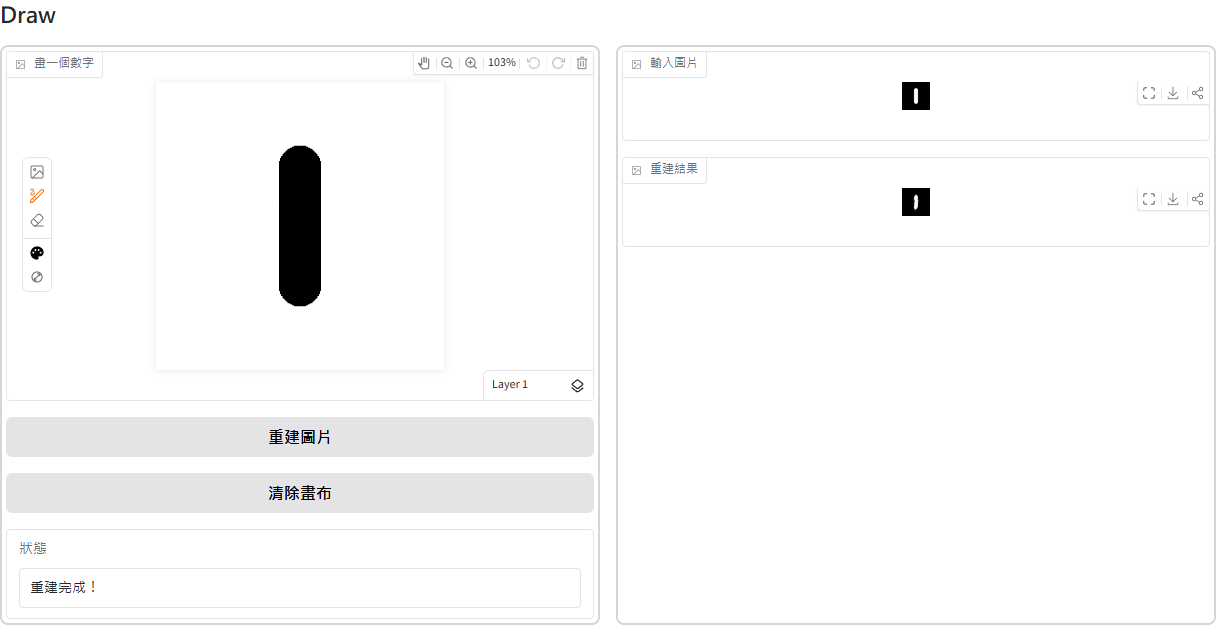
*在畫布上手繪一條直線(像數字「1」)：輸入圖片與重建結果幾乎一致. *

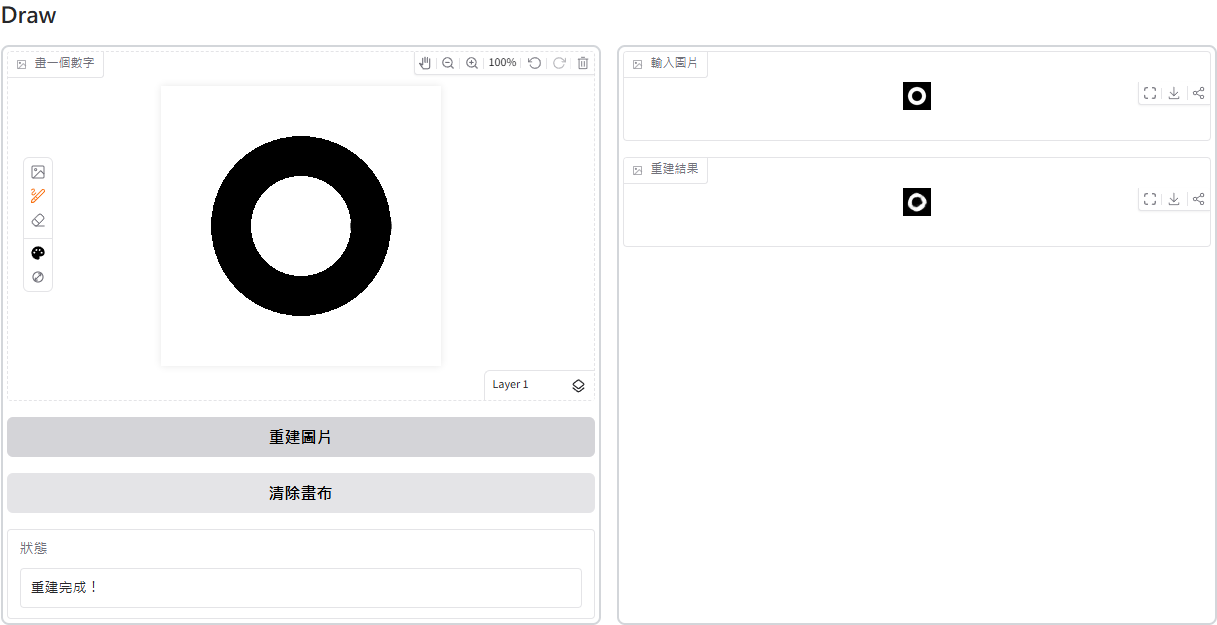
*在畫布上手繪一個圓環(像數字「0」)：輸入圖片與重建結果幾乎一致. *

##### Interface 3: Noise
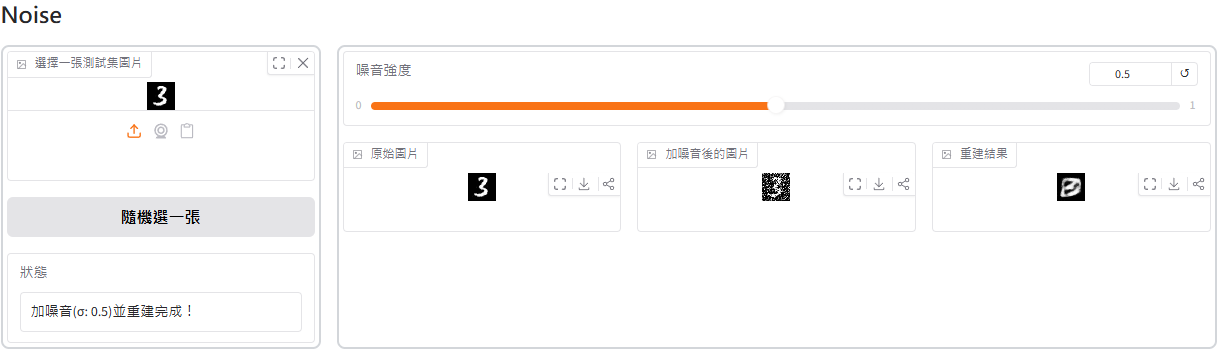
*數字「3」加上中等雜訊(σ = 0.5)：加噪圖已明顯模糊, 重建結果已無法理解. *

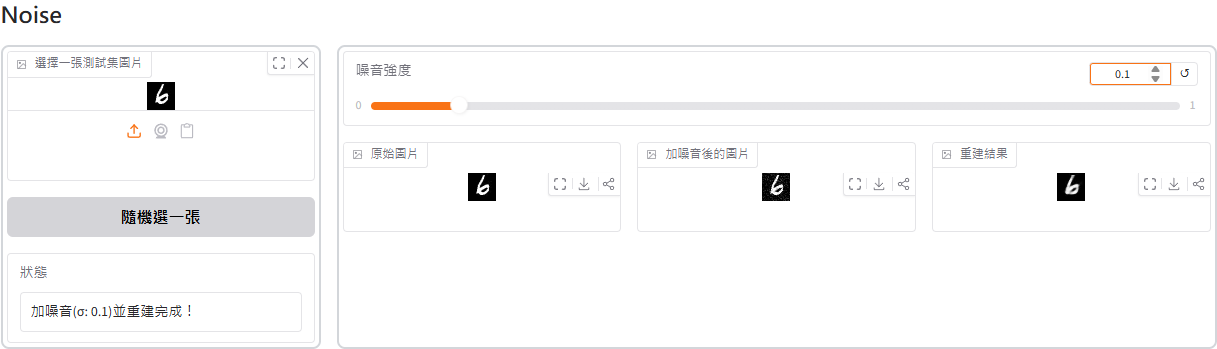
*數字「6」加上低雜訊(σ = 0.1)：加噪圖幾乎與原圖相同, 重建結果也幾乎一致. *

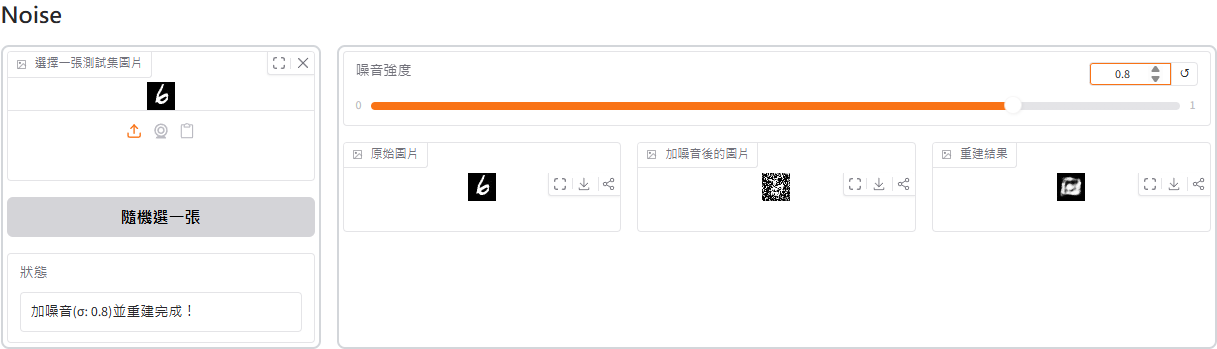
*數字「6」加上高雜訊(σ = 0.8)：加噪圖幾乎全毀, 重建結果已無法理解. *

##### Interface 4: Garbage in
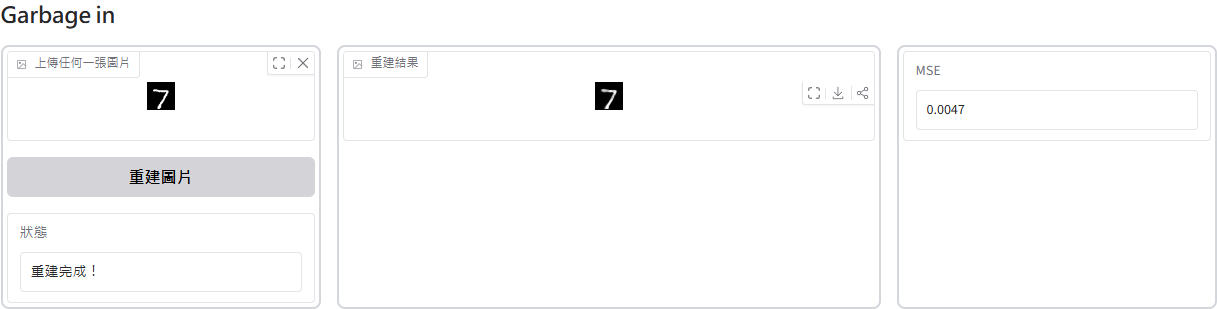
**圖一：**輸入一個真數字(7), 模型重建正確, MSE = 0.0047. 

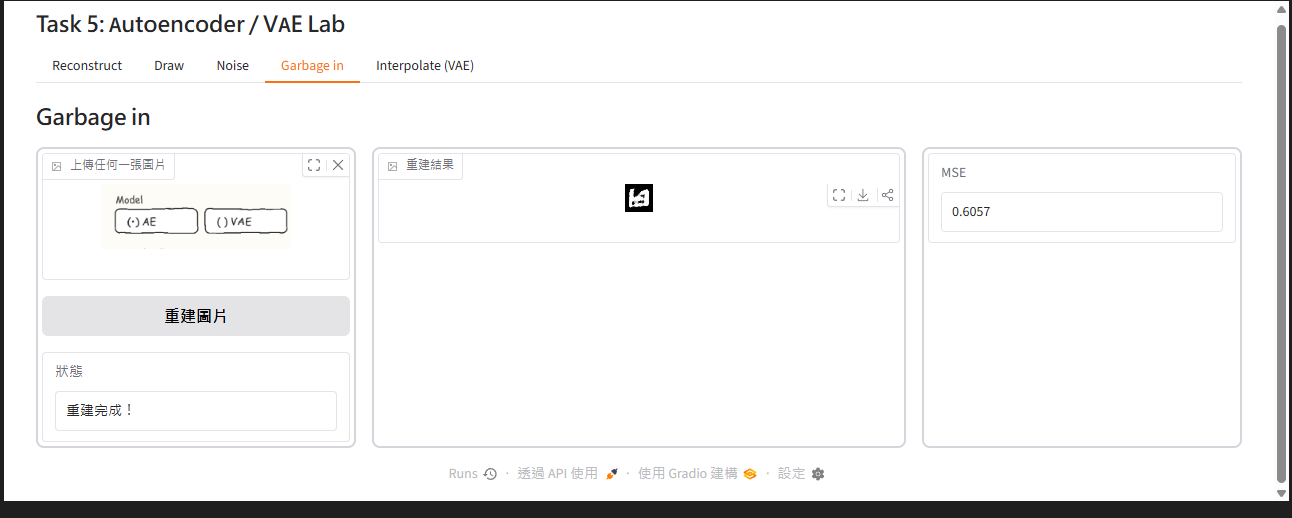
**圖二：**輸入一個隨機截取的截圖, 模型重建成一個無意義的圖像, MSE = 0.6205. 

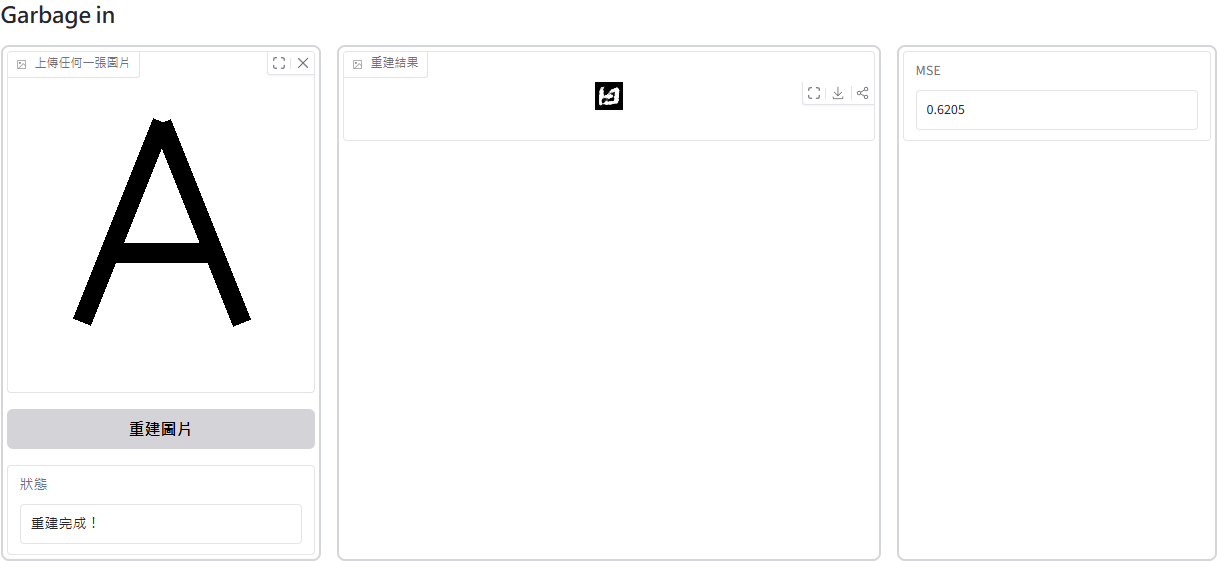
**圖三：**輸入一個大寫 A 的圖片, 模型重建成一個無意義的圖像, MSE = 0.6205. 
, 
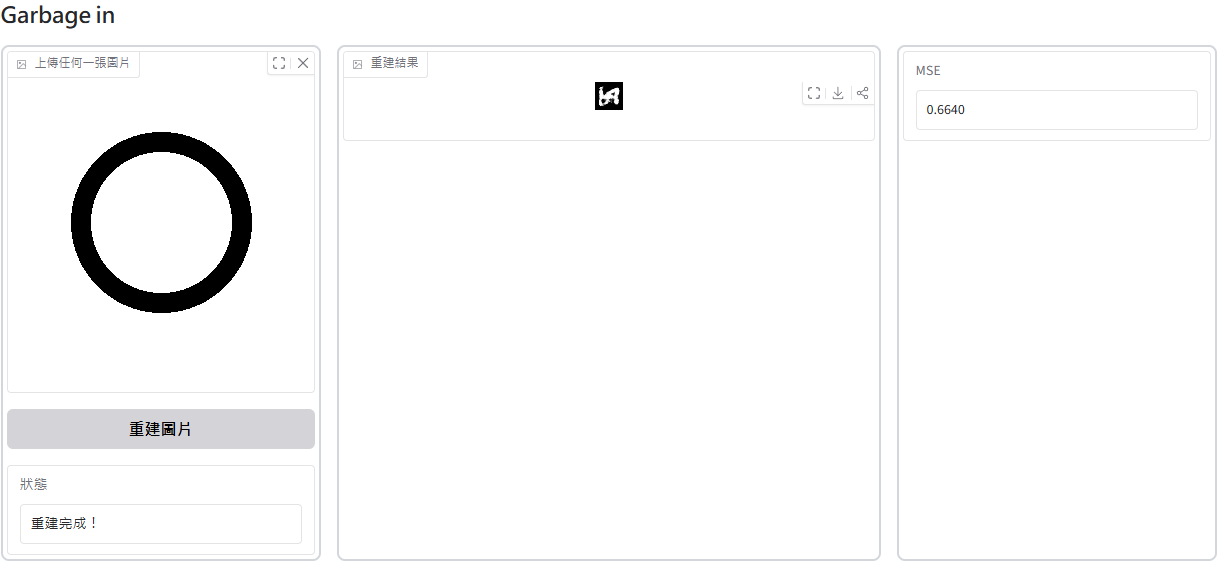
**圖四：**輸入一個圓圈的圖片, 模型重建成一個無意義的圖像, MSE = 0.6640. 

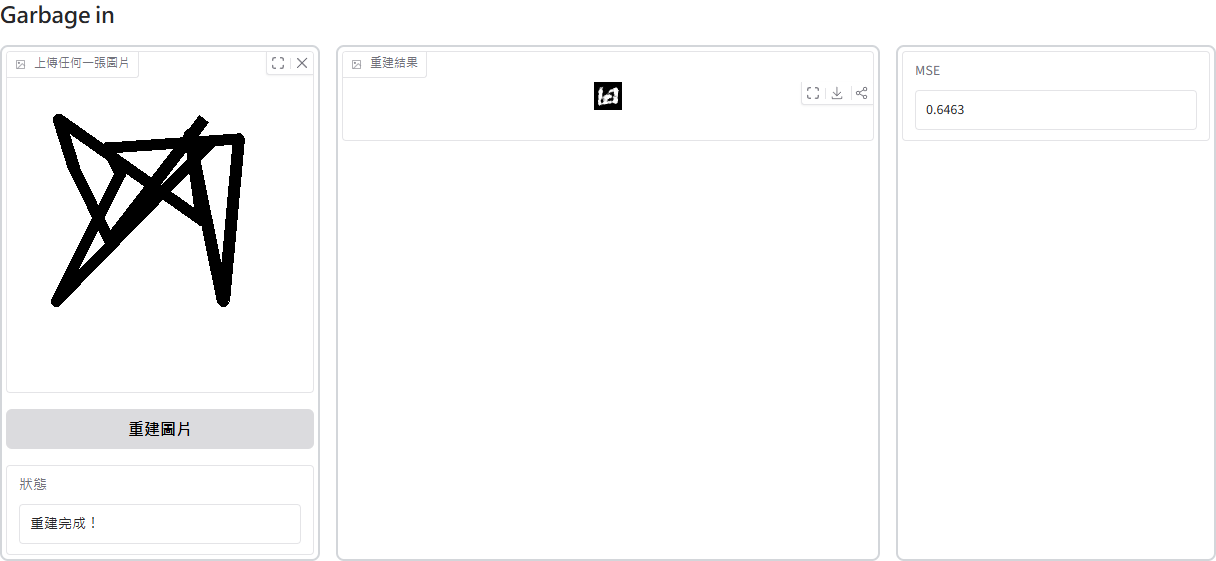
**圖五：**輸入一個隨機塗鴉的圖片, 模型重建成一個無意義的圖像, MSE = 0.6463. 

**Q1. What does the model produce when the input is not a digit, and why?**

模型輸出的是一團完全無法辨識、讀不出任何意義的圖像,既不像原本的輸入, 而不是某個數字的模糊版本. 原因是這個 autoencoder 只在 MNIST 手寫數字上訓練過, 它的 latent 空間與解碼器只學過"數字"這個流形. 當輸入落在訓練分布之外時, 模型只能輸出讀不出任何意義的圖像. 

**Q2. Could the MSE tell you whether an input is a digit? Use your numbers.**

可以, 數字「7」的 MSE 只有 0.0047, 而非數字的 MSE 都很高：A = 0.6205、圓圈 = 0.6640、塗鴉 = 0.6463, 相差超過兩個數量級. 模型對數字能精準重建,誤差極小;但對非數字則只能輸出的是一團完全無法辨識、讀不出任何意義的圖像,誤差很大, 所以只要設一個門檻(例如 MSE > 0.1)就能判斷輸入是否為數字. 不過這是"相對於這個模型"」"的判斷：如果某個非數字剛好長得像數字, MSE 也可能偏低, 因此 MSE 是必要但不完全充分的指標. 

##### Interface 5: Interpolate (VAE only)
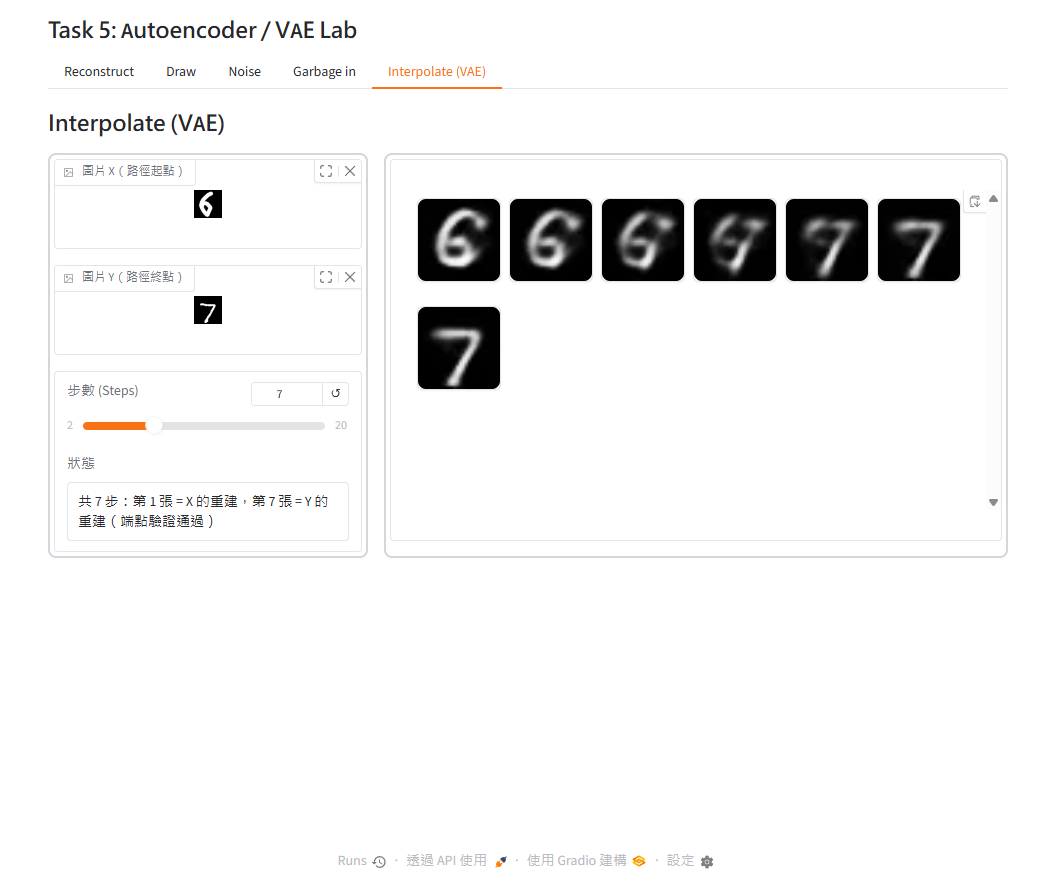
*在 VAE 的 latent 空間中對「6」與「7」兩張圖的 μ 做線性插值, 共 7 步：路徑由 6 逐漸過渡到 7, 中間出現類似 9 的過渡形狀. 狀態列顯示「共 7 步：第 1 張 = X 的重建, 第 7 張 = Y 的重建(端點驗證通過)」. *

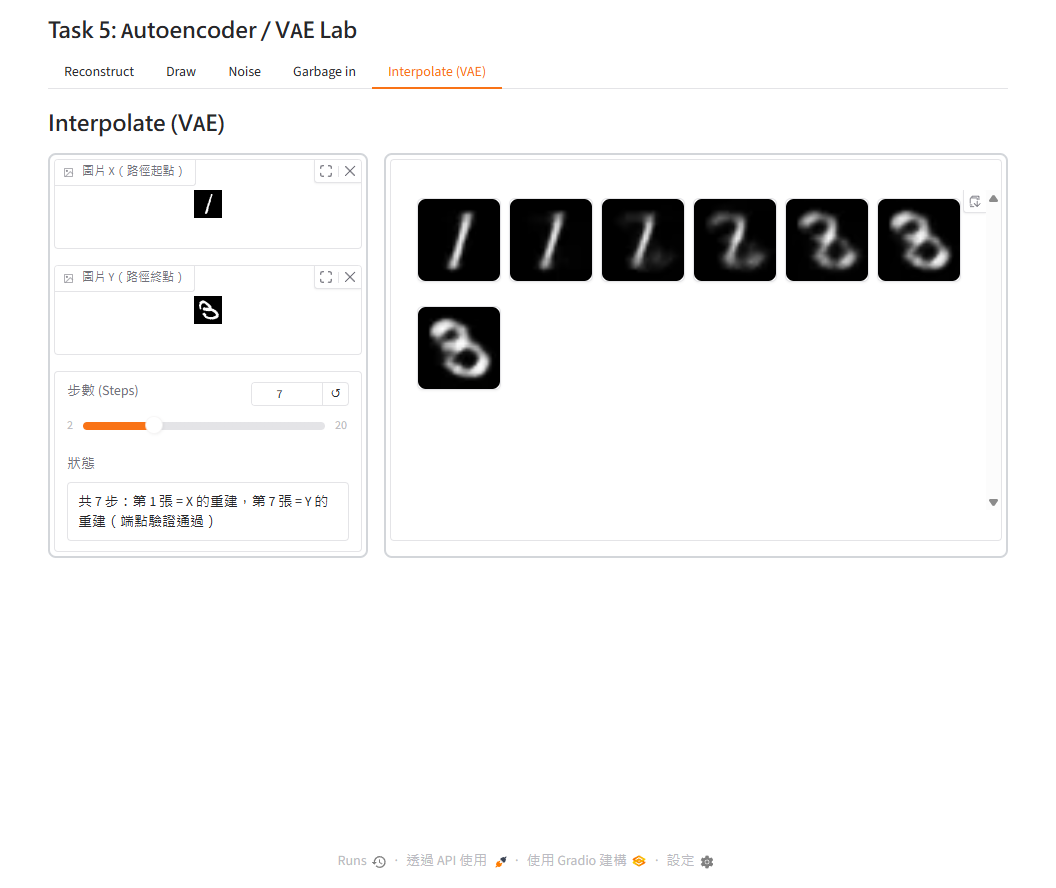
*在 VAE 的 latent 空間中對「1」與「3」兩張圖的 μ 做線性插值, 共 7 步：路徑由 1 逐漸過渡到 3, 中間經過類似 2 的形狀. 端點同樣驗證通過. *